<a href="https://colab.research.google.com/github/Raphaellazt/Customer-Lifetime-Value/blob/main/Customer_Lifetime_Value_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn scipy plotly joblib

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/mar-antaya/ml-portfolio-course/main/ecommerce_data.csv')
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
# First look at the data
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (8205, 7)

First 5 rows:


,CustomerID,InvoiceDate,Quantity,UnitPrice,TotalAmount,Country,ProductCategory
0,C0045,2022-08-24,2,39.69,79.39,UK,Books
1,C0757,2022-07-01,1,414.09,414.09,Netherlands,Sports
2,C1643,2022-01-05,1,358.44,358.44,NaN,Sports
3,C0133,2023-07-01,1,150.21,150.21,UK,Clothing
4,C0941,2022-12-10,1,222.65,222.65,UK,Sports


In [62]:
# Quick preview of data
print("Dataset shape:", df.shape)
print("Unique customers:", df['CustomerID'].nunique())
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (8205, 7)
Unique customers: 1847
Date range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00

First 5 rows:
  CustomerID InvoiceDate  Quantity  UnitPrice  TotalAmount      Country  \
0      C0045  2022-08-24         2      39.69        79.39           UK   
1      C0757  2022-07-01         1     414.09       414.09  Netherlands   
2      C1643  2022-01-05         1     358.44       358.44          NaN   
3      C0133  2023-07-01         1     150.21       150.21           UK   
4      C0941  2022-12-10         1     222.65       222.65           UK   

  ProductCategory  
0           Books  
1          Sports  
2          Sports  
3        Clothing  
4          Sports  


In [63]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())
# Check data types
print("\nData Types:")
print(df.dtypes)
# Check for negative values where they shouldn't exist
print("\nNegative values check:")
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Negative UnitPrice:", (df['UnitPrice'] < 0).sum())

Duplicate rows: 0

Data Types:
CustomerID                 object
InvoiceDate        datetime64[ns]
Quantity                    int64
UnitPrice                 float64
TotalAmount               float64
Country                    object
ProductCategory            object
dtype: object

Negative values check:
Negative Quantity: 65
Negative UnitPrice: 0


In [64]:
# Detailed missing value analysis
missing_data= df.isnull().sum()
missing_percent= 100 * missing_data / len(df)
missing_df= pd.DataFrame({
'Missing_Count': missing_data,
'Missing_Percent': missing_percent
})
print(missing_df[missing_df['Missing_Count'] > 0])

            Missing_Count  Missing_Percent
CustomerID             16         0.195003
Country              1339        16.319317


In [65]:
# Statistical outlier detection for TotalAmount
Q1= df['TotalAmount'].quantile(0.25)
Q3= df['TotalAmount'].quantile(0.75)
IQR= Q3- Q1
# Define outlier boundaries
lower_bound= Q1- 1.5 * IQR
upper_bound= Q3 + 1.5 * IQR
# Identify outliers
outliers = df[(df['TotalAmount'] < lower_bound) | (df['TotalAmount'] > upper_bound)]
print(f"Found {len(outliers)} outliers out of {len(df)} transactions")

Found 555 outliers out of 8205 transactions


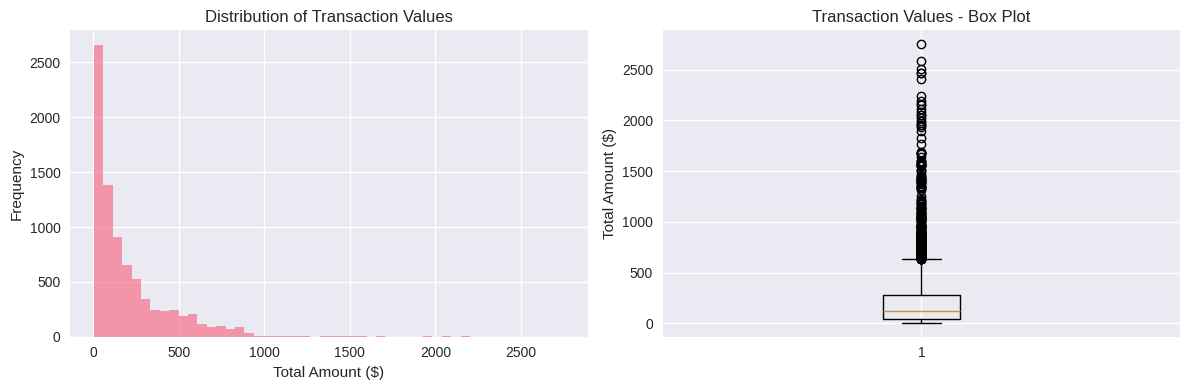

In [66]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['TotalAmount'], bins=50, alpha=0.7)
plt.title('Distribution of Transaction Values')
plt.xlabel('Total Amount ($)')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.boxplot(df['TotalAmount'])
plt.title('Transaction Values - Box Plot')
plt.ylabel('Total Amount ($)')
plt.tight_layout()
plt.show()

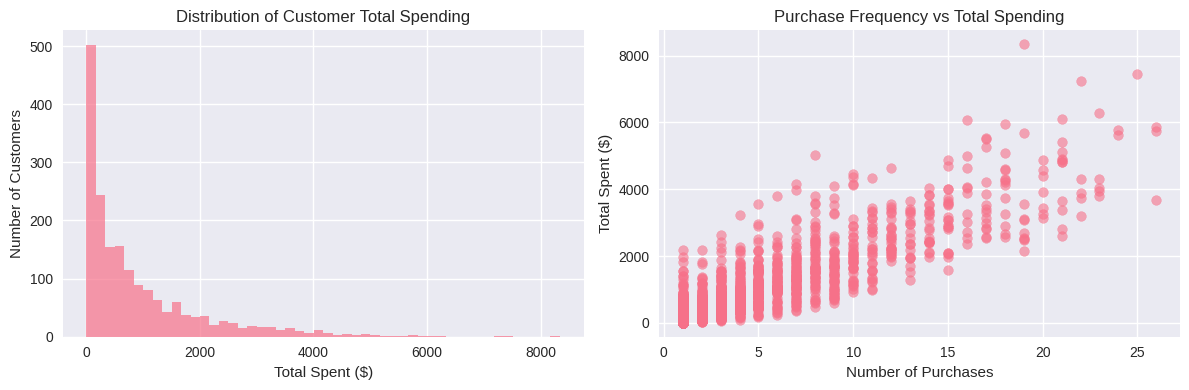

In [67]:
# Analyze customer behavior
customer_stats= df.groupby('CustomerID').agg({
'TotalAmount': ['sum', 'mean', 'count'],
'InvoiceDate': ['min', 'max']
}).round(2)
# Flatten column names
customer_stats.columns = ['Total_Spent', 'Avg_Order_Value', 'Purchase_Count', 'First_Purchase', 'Last_Purchase']
# Plot customer value distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(customer_stats['Total_Spent'], bins=50, alpha=0.7)
plt.title('Distribution of Customer Total Spending')
plt.xlabel('Total Spent ($)')
plt.ylabel('Number of Customers')
plt.subplot(1, 2, 2)
plt.scatter(customer_stats['Purchase_Count'], customer_stats['Total_Spent'], alpha=0.6)
plt.title('Purchase Frequency vs Total Spending')
plt.xlabel('Number of Purchases')
plt.ylabel('Total Spent ($)')
plt.tight_layout()
plt.show()

In [68]:
# Create a copy for cleaning
df_clean= df.copy()
# 1. Remove rows without CustomerID (can't calculate CLV)
df_clean= df_clean.dropna(subset=['CustomerID'])
# 2. Fill missing countries
df_clean['Country']= df_clean['Country'].fillna('Unknown')
# 3. Remove negative quantities (likely returns or errors)
df_clean= df_clean[df_clean['Quantity'] > 0]
# 4. Remove zero or negative prices
df_clean= df_clean[df_clean['UnitPrice'] > 0]
# 5. Convert InvoiceDate to datetime
df_clean['InvoiceDate']= pd.to_datetime(df_clean['InvoiceDate'])
# 6. Handle extreme outliers (keep top 1% for analysis but flag them)
upper_99= df_clean['TotalAmount'].quantile(0.99)
df_clean['High_Value_Flag']= df_clean['TotalAmount'] > upper_99
print(f"Original dataset: {len(df)} rows")
print(f"Cleaned dataset: {len(df_clean)} rows")
print(f"Rows removed: {len(df)- len(df_clean)} ({((len(df)- len(df_clean))/len(df)*100):.1f}%)")

Original dataset: 8205 rows
Cleaned dataset: 8100 rows
Rows removed: 105 (1.3%)


In [69]:
cutoff = df_clean['InvoiceDate'].min() + pd.DateOffset(months=9)
df_features= df_clean[df_clean['InvoiceDate'] <= cutoff].copy()
df_target= df_clean[df_clean['InvoiceDate'] > cutoff].copy()
print(f"Feature window: {df_features['InvoiceDate'].min().date()} → {df_features['InvoiceDate'].max().date()}")
print(f"Target window: {df_target['InvoiceDate'].min().date()} → {df_target['InvoiceDate'].max().date()}")
analysis_date= cutoff + pd.Timedelta(days=1)
recency = (
df_features.groupby('CustomerID')['InvoiceDate']
.apply(lambda x: (analysis_date- x.max()).days)
.rename('Recency')
)
freq_monetary= df_features.groupby('CustomerID')['TotalAmount'].agg(
Frequency='count',
MonetaryValue='sum',
AvgOrderValue='mean'
).round(2)
rfm = pd.concat([recency, freq_monetary], axis=1)
clv_target= (
df_target.groupby('CustomerID')['TotalAmount']
.sum()
.rename('CLV')
)
rfm = rfm.join(clv_target, how='inner').fillna({'CLV': 0})
print(f"\nFinal modelling dataset: {len(rfm)} customers")
print(f"Average future CLV: ${rfm['CLV'].mean():.2f}")
corr = rfm['MonetaryValue'].corr(rfm['CLV'])
print(f"\nCorrelation check: {corr:.3f}")
if corr > 0.95:
    print("⚠️ WARNING: possible data leakage")
else:
    print("✅ No data leakage detected")

Feature window: 2022-01-01 → 2022-10-01
Target window: 2022-10-02 → 2023-12-31

Final modelling dataset: 504 customers
Average future CLV: $948.61

Correlation check: 0.042
✅ No data leakage detected


In [70]:
# Final quality checks
print("=== CLEANED DATA QUALITY REPORT ===")
print(f"Total customers: {df_clean['CustomerID'].nunique()}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Total revenue: ${df_clean['TotalAmount'].sum():,.2f}")
print(f"Average order value: ${df_clean['TotalAmount'].mean():.2f}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")
# Check for any remaining data quality issues
assert df_clean['Quantity'].min() > 0, "Still have negative quantities"
assert df_clean['UnitPrice'].min() > 0, "Still have negative prices"
assert df_clean['CustomerID'].isnull().sum()== 0, "Still have missing CustomerIDs"
print("\n✅ Data cleaning completed successfully!")

=== CLEANED DATA QUALITY REPORT ===
Total customers: 1840
Date range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00
Total revenue: $1,723,734.05
Average order value: $212.81
Remaining missing values: 0

✅ Data cleaning completed successfully!


In [71]:
import warnings
warnings.filterwarnings('ignore')
# Calculate customer purchase trends
def calculate_trends(customer_df):
    """Calculate purchase behavior trends for a customer"""
    if len(customer_df) < 2:
        return 0, 0 # Not enough data for trends
    # Sort by date
    customer_df= customer_df.sort_values('InvoiceDate')
    # Calculate time between purchases
    time_diffs= customer_df['InvoiceDate'].diff().dt.days.dropna()
    avg_days_between= time_diffs.mean() if len(time_diffs) > 0 else 0
    # Calculate spending trend (increasing/decreasing)
    amounts = customer_df['TotalAmount'].values
    if len(amounts) >= 3:
        x = np.arange(len(amounts))
        corr = np.corrcoef(x, amounts)[0,1]
        spending_trend= 0 if np.isnan(corr) else corr
    else:
        spending_trend= 0
    return avg_days_between, spending_trend
# Apply to all customers using df_features (feature window only)
trends = df_features.groupby('CustomerID', group_keys=False).apply(
    lambda x: pd.Series(calculate_trends(x),
    index=['AvgDaysBetween', 'SpendingTrend'])
)
# Drop if already exists (prevents error if cell is run twice)
rfm = rfm.drop(columns=['AvgDaysBetween', 'SpendingTrend'], errors='ignore')
rfm = rfm.join(trends)
print("Behavioral trends added ✅")
print(rfm[['Recency', 'Frequency', 'MonetaryValue', 'AvgDaysBetween', 'SpendingTrend']].head())

Behavioral trends added ✅
            Recency  Frequency  MonetaryValue  AvgDaysBetween  SpendingTrend
CustomerID                                                                  
C0002            36          2         167.73            16.0            0.0
C0003             3          2          99.65            20.0            0.0
C0011            99          1          33.60             0.0            0.0
C0016             5          2         529.62             2.0            0.0
C0019            43          2          38.70            37.0            0.0


In [72]:
# Calculate customer lifecycle metrics
lifecycle= df_features.groupby('CustomerID')['InvoiceDate'].agg(['min', 'max'])
lifecycle['TenureDays']= (lifecycle['max']- lifecycle['min']).dt.days
lifecycle['DaysSinceFirst']= (analysis_date- lifecycle['min']).dt.days
lifecycle['DaysSinceLast']= (analysis_date- lifecycle['max']).dt.days
# Add to feature set
rfm = rfm.drop(columns=['TenureDays', 'DaysSinceFirst', 'DaysSinceLast'], errors='ignore')
rfm = rfm.join(lifecycle[['TenureDays', 'DaysSinceFirst', 'DaysSinceLast']])
print("Lifecycle features added ✅\n")
print(rfm[['Recency', 'TenureDays', 'DaysSinceFirst', 'DaysSinceLast']].head())

Lifecycle features added ✅

            Recency  TenureDays  DaysSinceFirst  DaysSinceLast
CustomerID                                                    
C0002            36          16              52             36
C0003             3          20              23              3
C0011            99           0              99             99
C0016             5           2               7              5
C0019            43          37              80             43


In [73]:
# Purchase pattern features
purchase_patterns= df_features.groupby('CustomerID').agg(
TotalQuantity=('Quantity', 'sum'),
AvgQuantity=('Quantity', 'mean'),
QuantityStd=('Quantity', 'std'),
AvgUnitPrice=('UnitPrice', 'mean'),
UnitPriceStd=('UnitPrice', 'std'),
MinPurchase=('TotalAmount', 'min'),
MaxPurchase=('TotalAmount', 'max'),
PurchaseStd=('TotalAmount', 'std')
).round(2)
# Drop if already exists (prevents error if cell is run twice)
rfm = rfm.drop(columns=purchase_patterns.columns.tolist(), errors='ignore')
rfm = rfm.join(purchase_patterns)
print("Purchase patterns added ✅")
print(rfm[['TotalQuantity', 'AvgQuantity', 'MinPurchase', 'MaxPurchase']].head())

Purchase patterns added ✅
            TotalQuantity  AvgQuantity  MinPurchase  MaxPurchase
CustomerID                                                      
C0002                   2          1.0         8.98       158.75
C0003                   4          2.0        18.25        81.40
C0011                   1          1.0        33.60        33.60
C0016                   2          1.0        12.02       517.60
C0019                   2          1.0         9.65        29.05


In [74]:
# Fill missing values
rfm['QuantityStd']= rfm['QuantityStd'].fillna(0)
rfm['UnitPriceStd']= rfm['UnitPriceStd'].fillna(0)
rfm['PurchaseStd']= rfm['PurchaseStd'].fillna(0)
rfm['SpendingTrend']= rfm['SpendingTrend'].fillna(0)
rfm['AvgDaysBetween']= rfm['AvgDaysBetween'].fillna(0)
# Ratio features
rfm['ValuePerPurchase']= rfm['MonetaryValue'] / rfm['Frequency']
rfm['PurchaseFrequency']= rfm['Frequency'] / (rfm['TenureDays'] + 1)
print("Missing values filled and ratio features added ✅")
print(rfm[['MonetaryValue', 'Frequency', 'ValuePerPurchase', 'PurchaseFrequency']].head())
print(f"\nAny remaining missing values: {rfm.isnull().sum().sum()}")

Missing values filled and ratio features added ✅
            MonetaryValue  Frequency  ValuePerPurchase  PurchaseFrequency
CustomerID                                                               
C0002              167.73          2            83.865           0.117647
C0003               99.65          2            49.825           0.095238
C0011               33.60          1            33.600           1.000000
C0016              529.62          2           264.810           0.666667
C0019               38.70          2            19.350           0.052632

Any remaining missing values: 0


In [75]:
# Create customer segments based on RFM scores
def rfm_segment(row):
    if row['Recency'] <= 30 and row['Frequency'] >= 5 and row['MonetaryValue'] >= 500:
        return 'Champions'
    elif row['Recency'] <= 30 and row['Frequency'] >= 3:
        return 'Loyal Customers'
    elif row['MonetaryValue'] >= 300:
        return 'Big Spenders'
    elif row['Recency'] <= 60:
        return 'Potential Loyalists'
    elif row['Recency'] > 180:
        return 'At Risk'
    else:
        return 'Regular'
rfm['CustomerSegment']= rfm.apply(rfm_segment, axis=1)
# Convert to dummy variables for modeling
segment_dummies= pd.get_dummies(rfm['CustomerSegment'], prefix='Segment')
rfm = rfm.drop(columns=[c for c in rfm.columns if c.startswith('Segment_')], errors='ignore')
rfm = rfm.join(segment_dummies)
print("Customer segments created ✅")
print(rfm['CustomerSegment'].value_counts())
print(f"\nSegment columns added: {[c for c in rfm.columns if c.startswith('Segment_')]}")

Customer segments created ✅
CustomerSegment
Big Spenders           164
Potential Loyalists    107
Champions               97
Loyal Customers         80
Regular                 53
At Risk                  3
Name: count, dtype: int64

Segment columns added: ['Segment_At Risk', 'Segment_Big Spenders', 'Segment_Champions', 'Segment_Loyal Customers', 'Segment_Potential Loyalists', 'Segment_Regular']


In [76]:
# Define feature columns
feature_columns= [
'Recency', 'Frequency', 'MonetaryValue',
'AvgDaysBetween', 'SpendingTrend',
'TenureDays', 'DaysSinceFirst', 'DaysSinceLast',
'TotalQuantity', 'AvgQuantity', 'AvgUnitPrice',
'MinPurchase', 'MaxPurchase', 'PurchaseStd',
'ValuePerPurchase', 'PurchaseFrequency'
] + [col for col in rfm.columns if col.startswith('Segment_')]
X = rfm[feature_columns].fillna(0)
y = rfm['CLV']
print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

Feature matrix shape: (504, 22)
Target variable shape: (504,)

Features: ['Recency', 'Frequency', 'MonetaryValue', 'AvgDaysBetween', 'SpendingTrend', 'TenureDays', 'DaysSinceFirst', 'DaysSinceLast', 'TotalQuantity', 'AvgQuantity', 'AvgUnitPrice', 'MinPurchase', 'MaxPurchase', 'PurchaseStd', 'ValuePerPurchase', 'PurchaseFrequency', 'Segment_At Risk', 'Segment_Big Spenders', 'Segment_Champions', 'Segment_Loyal Customers', 'Segment_Potential Loyalists', 'Segment_Regular']


In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)
print(f"Training set: {X_train.shape[0]} customers")
print(f"Test set: {X_test.shape[0]} customers")
print("Features scaled and ready for modeling ✅")

Training set: 403 customers
Test set: 101 customers
Features scaled and ready for modeling ✅


In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
# Initialize the model
lr_model= LinearRegression()
# Train the model
print("Training Linear Regression model...")
lr_model.fit(X_train_scaled, y_train)
# Make predictions
y_train_pred= lr_model.predict(X_train_scaled)
y_test_pred= lr_model.predict(X_test_scaled)
print("✅ Model trained successfully!")

Training Linear Regression model...
✅ Model trained successfully!


In [79]:
# Calculate performance metrics
train_mae= mean_absolute_error(y_train, y_train_pred)
test_mae= mean_absolute_error(y_test, y_test_pred)
train_rmse= np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse= np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2= r2_score(y_train, y_train_pred)
test_r2= r2_score(y_test, y_test_pred)
print("=== MODEL PERFORMANCE ===")
print(f"Training MAE: ${train_mae:.2f}")
print(f"Test MAE: ${test_mae:.2f}")
print(f"Training RMSE: ${train_rmse:.2f}")
print(f"Test RMSE: ${test_rmse:.2f}")
print(f"Training R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")

=== MODEL PERFORMANCE ===
Training MAE: $711.04
Test MAE: $778.95
Training RMSE: $990.83
Test RMSE: $993.34
Training R²: 0.105
Test R²: 0.069


=== TOP 10 MOST IMPORTANT FEATURES ===
              Feature  Coefficient  Abs_Coefficient
14   ValuePerPurchase   336.285436       336.285436
15  PurchaseFrequency  -328.931683       328.931683
10       AvgUnitPrice  -215.177300       215.177300
12        MaxPurchase  -178.221691       178.221691
3      AvgDaysBetween  -150.812710       150.812710
6      DaysSinceFirst   -96.963073        96.963073
18  Segment_Champions    87.947643        87.947643
13        PurchaseStd    71.603736        71.603736
7       DaysSinceLast   -67.646040        67.646040
0             Recency   -67.646040        67.646040


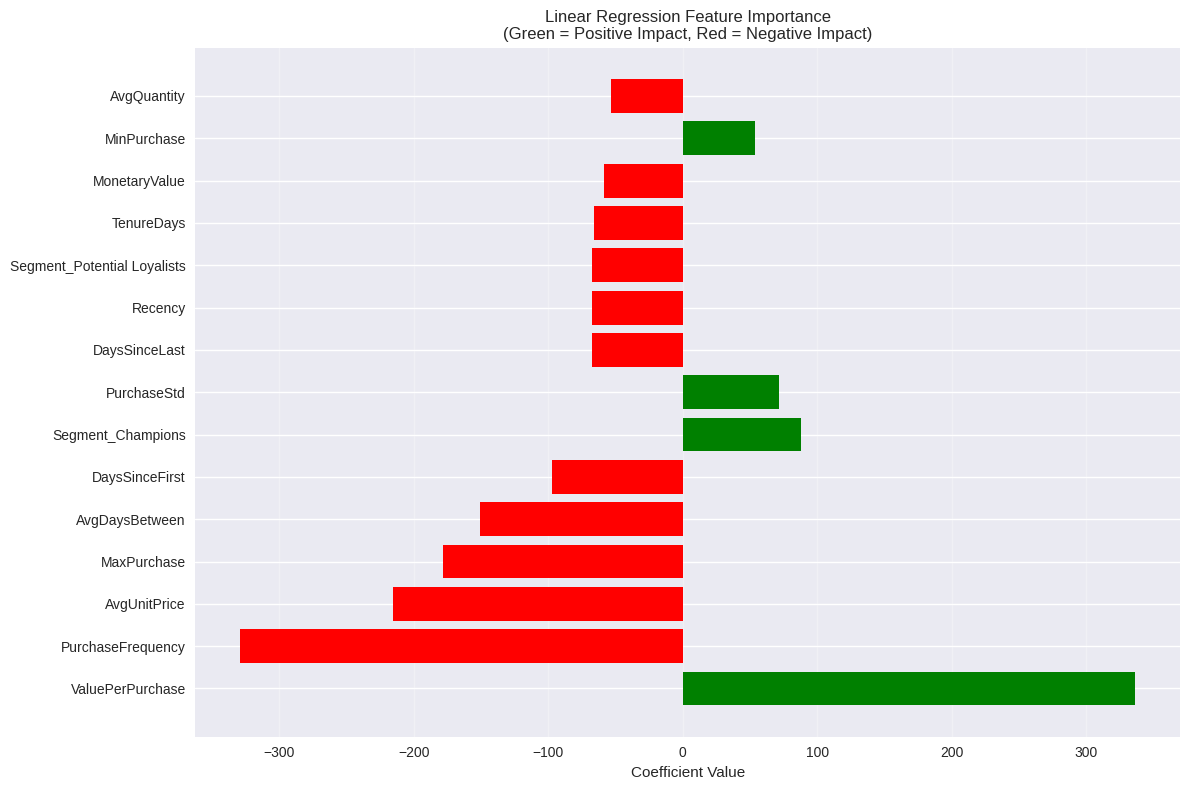

In [80]:
# Get feature importance from coefficients
feature_importance= pd.DataFrame({
'Feature': feature_columns,
'Coefficient': lr_model.coef_,
'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)
print("=== TOP 10 MOST IMPORTANT FEATURES ===")
print(feature_importance.head(10))
plt.figure(figsize=(12, 8))
top_features= feature_importance.head(15)
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Feature Importance\n(Green = Positive Impact, Red = Negative Impact)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
# Show top 5 most important features with direction
print("=== BUSINESS INSIGHTS FROM MODEL ===\n")
for idx, row in feature_importance.head(5).iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    direction = "increases" if coef > 0 else "decreases"
    print(f"\n{feature}") # Print feature name on a new line for readability
    print(f" \u2192 Higher {feature} {direction} predicted CLV")
    print() # Add a blank line for visual separation between insights

=== BUSINESS INSIGHTS FROM MODEL ===


ValuePerPurchase
 → Higher ValuePerPurchase increases predicted CLV


PurchaseFrequency
 → Higher PurchaseFrequency decreases predicted CLV


AvgUnitPrice
 → Higher AvgUnitPrice decreases predicted CLV


MaxPurchase
 → Higher MaxPurchase decreases predicted CLV


AvgDaysBetween
 → Higher AvgDaysBetween decreases predicted CLV



=== SAMPLE PREDICTIONS ===
   Actual_CLV  Predicted_CLV  Prediction_Error  Percent_Error
0       57.89         958.55           -900.66        1555.81
1      225.83         913.28           -687.45         304.41
2      826.67         493.83            332.84          40.26
3      258.26         809.28           -551.02         213.36
4     1661.03        1447.31            213.72          12.87
5      546.14        1458.83           -912.69         167.12
6       89.91        1135.45          -1045.54        1162.87
7       38.82        1690.11          -1651.29        4253.70
8     2829.33         879.83           1949.50          68.90
9      895.22        1326.49           -431.27          48.17


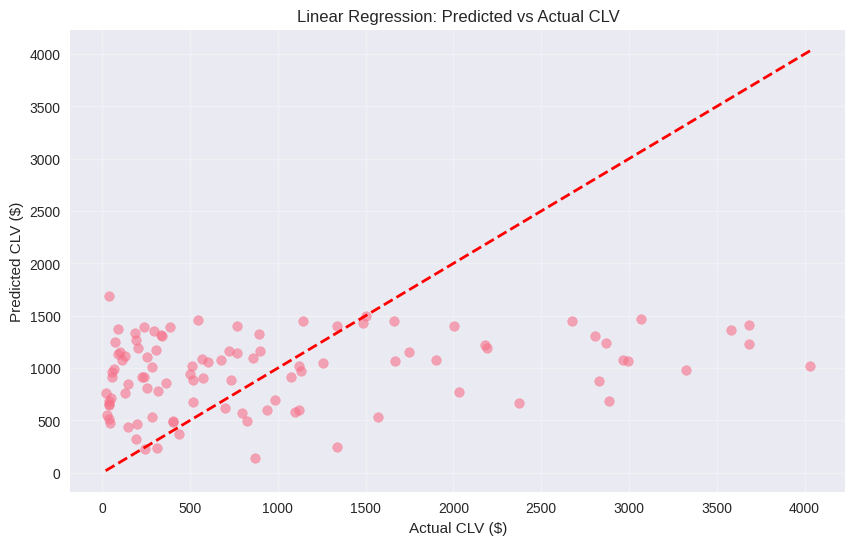

In [82]:
# Make predictions on test set
predictions_df= pd.DataFrame({
'Actual_CLV': y_test.values,
'Predicted_CLV': y_test_pred,
'Prediction_Error': y_test.values- y_test_pred
})
# Add percentage error
predictions_df['Percent_Error']= abs(predictions_df['Prediction_Error']) / predictions_df['Actual_CLV'] * 100
print("=== SAMPLE PREDICTIONS ===")
print(predictions_df.head(10).round(2))
# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(predictions_df['Actual_CLV'], predictions_df['Predicted_CLV'], alpha=0.6)
plt.plot([predictions_df['Actual_CLV'].min(), predictions_df['Actual_CLV'].max()],
[predictions_df['Actual_CLV'].min(), predictions_df['Actual_CLV'].max()],
'r--', linewidth=2)
plt.xlabel('Actual CLV ($)')
plt.ylabel('Predicted CLV ($)')
plt.title('Linear Regression: Predicted vs Actual CLV')
plt.grid(alpha=0.3)
plt.show()

In [83]:
def predict_customer_clv(model, scaler, customer_features):
    """Predict CLV for a new customer"""
    # Scale the features
    features_scaled= scaler.transform([customer_features])
    # Make prediction
    clv_prediction= model.predict(features_scaled)[0]
    return clv_prediction

# Example: Predict CLV for a hypothetical customer
new_customer= {
    'Recency': 15, # Last purchase 15 days ago
    'Frequency': 8, # 8 total purchases
    'MonetaryValue': 450, # $450 total spent
    'AvgDaysBetween': 30, # Purchases every 30 days
    'SpendingTrend': 0.1, # Slightly increasing spend
    'TenureDays': 240, # Customer for 8 months
    # ... (other features would be calculated)
}

# For demo, let's predict on a real test customer
sample_customer= X_test.iloc[0].values
predicted_clv= predict_customer_clv(lr_model, scaler, sample_customer)
actual_clv= y_test.iloc[0]

print(f"Sample Customer Prediction:")
print(f"Predicted CLV: ${predicted_clv:.2f}")
print(f"Actual CLV: ${actual_clv:.2f}")
print(f"Prediction Error: ${abs(predicted_clv- actual_clv):.2f}")

Sample Customer Prediction:
Predicted CLV: $958.55
Actual CLV: $57.89
Prediction Error: $900.66


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Added numpy import

# Calculate comprehensive metrics
def evaluate_model(y_true, y_pred, model_name):
    """Comprehensive model evaluation"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # Calculate percentage errors
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    # Business metrics
    revenue_impact= np.sum(np.abs(y_true - y_pred))
    print(f"=== {model_name} PERFORMANCE ===")
    print(f"R² Score: {r2:.3f}")
    print(f"MAE: ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAPE: {mape:.1f}%")
    print(f"Total Revenue Prediction Error: ${revenue_impact:,.2f}")
    return {
    'model': model_name,
    'r2': r2,
    'mae': mae,
    'rmse': rmse,
    'mape': mape,
    'revenue_impact': revenue_impact
    }

# Evaluate Linear Regression
lr_results= evaluate_model(y_test, y_test_pred, "Linear Regression")

=== Linear Regression PERFORMANCE ===
R² Score: 0.069
MAE: $778.95
RMSE: $993.34
MAPE: 383.7%
Total Revenue Prediction Error: $78,673.98


=== ERROR ANALYSIS ===
Customers with >50% error: 67
Customers with >$100 error: 92

Worst predictions (>50% error): 67 customers
Average actual CLV for high-error customers: $888.96


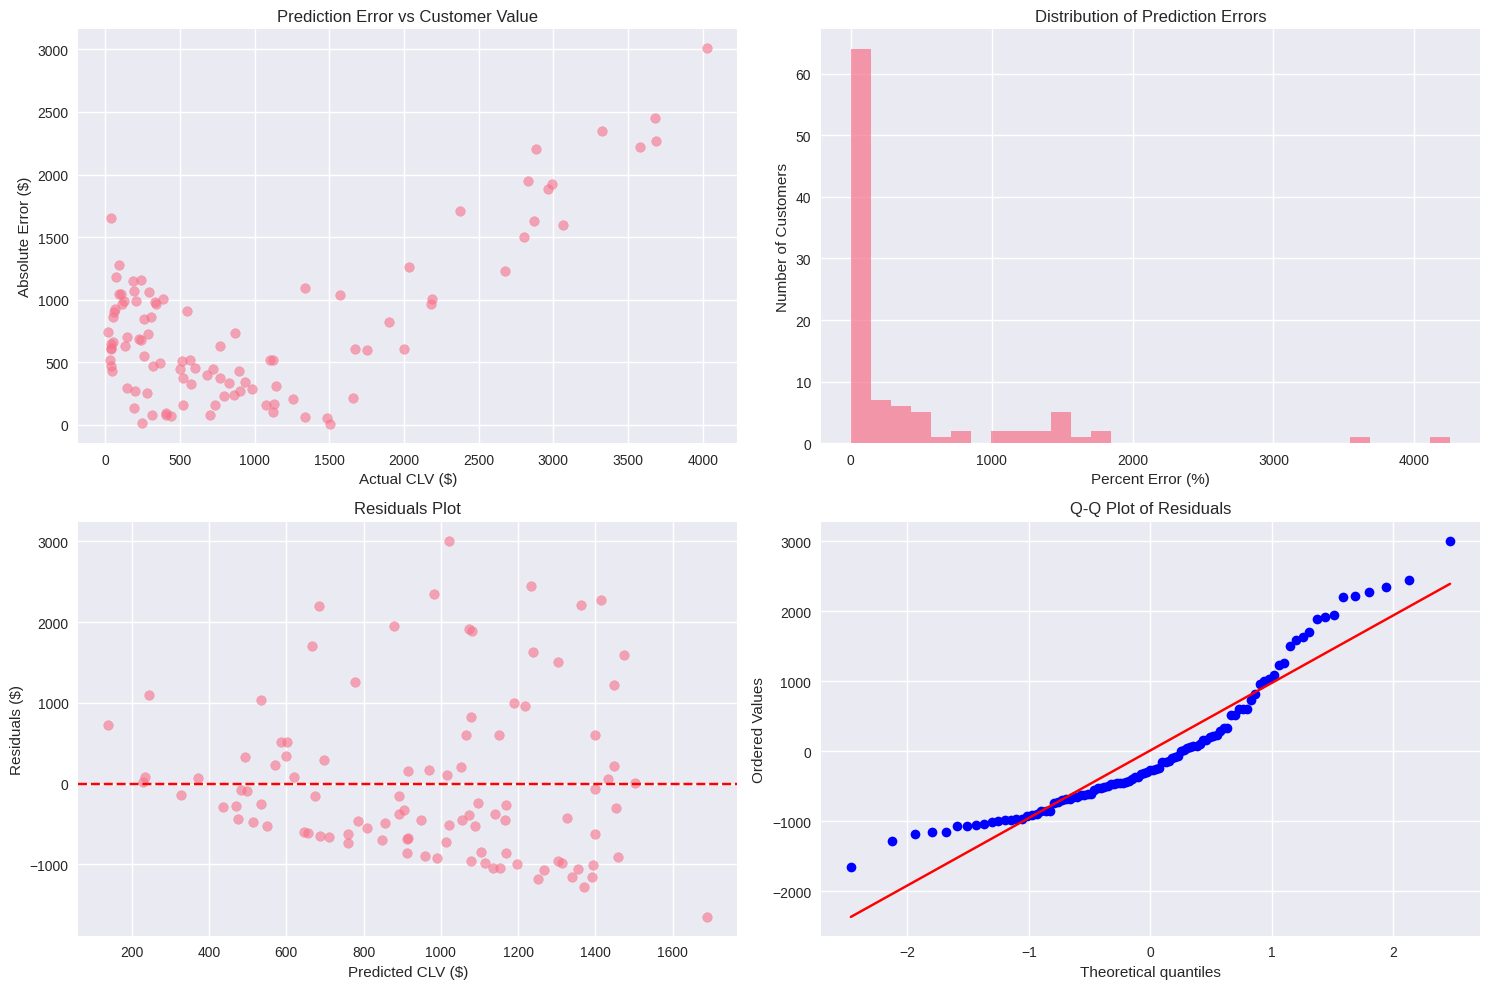

In [85]:
# Create error analysis dataframe
error_analysis= pd.DataFrame({
'Actual_CLV': y_test.values,
'Predicted_CLV': y_test_pred,
'Absolute_Error': np.abs(y_test.values- y_test_pred),
'Percent_Error': np.abs(y_test.values- y_test_pred) / y_test.values * 100
})
# Analyze error patterns
print("=== ERROR ANALYSIS ===")
print(f"Customers with >50% error: {(error_analysis['Percent_Error'] > 50).sum()}")
print(f"Customers with >$100 error: {(error_analysis['Absolute_Error'] > 100).sum()}")
# Find where we fail most
high_error_customers= error_analysis[error_analysis['Percent_Error'] > 50]
print(f"\nWorst predictions (>50% error): {len(high_error_customers)} customers")
print(f"Average actual CLV for high-error customers: ${high_error_customers['Actual_CLV'].mean():.2f}")
# Visualize error distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Error vs Actual CLV
axes[0,0].scatter(error_analysis['Actual_CLV'], error_analysis['Absolute_Error'], alpha=0.6)
axes[0,0].set_xlabel('Actual CLV ($)')
axes[0,0].set_ylabel('Absolute Error ($)')
axes[0,0].set_title('Prediction Error vs Customer Value')
# Error distribution
axes[0,1].hist(error_analysis['Percent_Error'], bins=30, alpha=0.7)
axes[0,1].set_xlabel('Percent Error (%)')
axes[0,1].set_ylabel('Number of Customers')
axes[0,1].set_title('Distribution of Prediction Errors')
# Residuals plot
residuals = error_analysis['Actual_CLV']- error_analysis['Predicted_CLV']
axes[1,0].scatter(error_analysis['Predicted_CLV'], residuals, alpha=0.6)
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_xlabel('Predicted CLV ($)')
axes[1,0].set_ylabel('Residuals ($)')
axes[1,0].set_title('Residuals Plot')
# Q-Q plot for normality check
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

In [86]:
from sklearn.ensemble import RandomForestRegressor
rf_model= RandomForestRegressor(
n_estimators=500,
max_depth=3,
min_samples_split=20,
min_samples_leaf=10,
max_features='sqrt',
random_state=42
)
print("Training Random Forest model...")
rf_model.fit(X_train_scaled, y_train)
rf_train_pred= rf_model.predict(X_train_scaled)
rf_test_pred= rf_model.predict(X_test_scaled)
print("✅ Random Forest trained successfully!")
rf_results= evaluate_model(y_test, rf_test_pred, "Random Forest")

Training Random Forest model...
✅ Random Forest trained successfully!
=== Random Forest PERFORMANCE ===
R² Score: 0.049
MAE: $784.75
RMSE: $1004.15
MAPE: 403.9%
Total Revenue Prediction Error: $79,259.67


In [87]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model= GradientBoostingRegressor(
n_estimators=100,
max_depth=3,
min_samples_split=20,
min_samples_leaf=10,
learning_rate=0.05,
random_state=42
)
print("Training Gradient Boosting model...")
gb_model.fit(X_train_scaled, y_train)
gb_train_pred= gb_model.predict(X_train_scaled)
gb_test_pred= gb_model.predict(X_test_scaled)
print("✅ Gradient Boosting trained successfully!")
gb_results= evaluate_model(y_test, gb_test_pred, "Gradient Boosting")

Training Gradient Boosting model...
✅ Gradient Boosting trained successfully!
=== Gradient Boosting PERFORMANCE ===
R² Score: -0.024
MAE: $809.87
RMSE: $1041.91
MAPE: 413.7%
Total Revenue Prediction Error: $81,796.66


In [88]:
import warnings
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import ConvergenceWarning
nn_model= MLPRegressor(
hidden_layer_sizes=(32, 16),
activation='relu',
alpha=0.01, max_iter=2000,
early_stopping=True, random_state=42
# L2 regularization -- matters a lot at this sample size
# stop once validation score stalls, rather than force-fitting
)
print("Training Neural Network model...")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    nn_model.fit(X_train_scaled, y_train)
nn_train_pred= nn_model.predict(X_train_scaled)
nn_test_pred= nn_model.predict(X_test_scaled)
print("✅ Neural Network trained successfully!")
nn_results= evaluate_model(y_test, nn_test_pred, "Neural Network")

Training Neural Network model...
✅ Neural Network trained successfully!
=== Neural Network PERFORMANCE ===
R² Score: 0.057
MAE: $765.54
RMSE: $999.83
MAPE: 390.1%
Total Revenue Prediction Error: $77,319.67


=== MODEL COMPARISON ===
               model        r2         mae         rmse        mape  \
0  Linear Regression  0.069074  778.950292   993.342673  383.739403   
1      Random Forest  0.048709  784.749243  1004.149059  403.947470   
2  Gradient Boosting -0.024176  809.867875  1041.906809  413.650282   
3     Neural Network  0.056875  765.541294   999.830131  390.144998   

   revenue_impact  
0    78673.979455  
1    79259.673552  
2    81796.655373  
3    77319.670654  


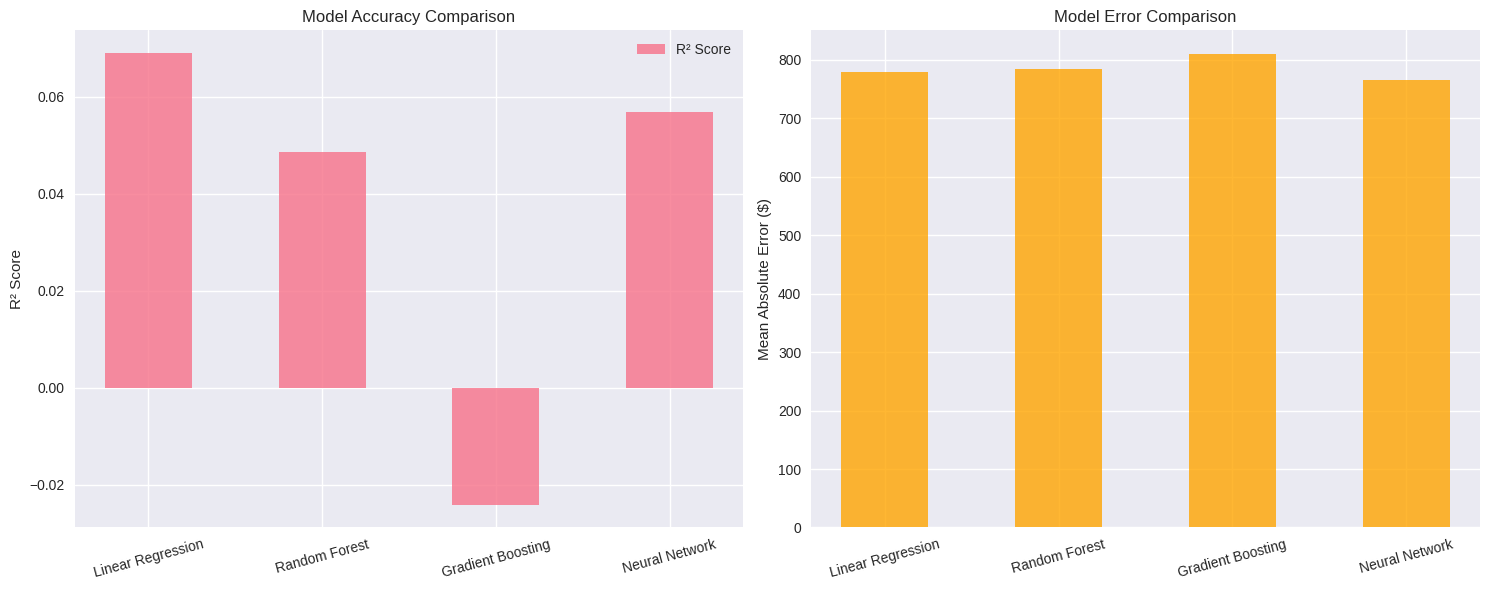

🏆 Linear Regression wins with R² of 0.069


In [89]:
# Create comparison dataframe
comparison= pd.DataFrame([lr_results, rf_results, gb_results, nn_results])
print("=== MODEL COMPARISON ===")
print(comparison)
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Prediction accuracy comparison
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Neural Network']
r2_scores= [lr_results['r2'], rf_results['r2'], gb_results['r2'], nn_results['r2']]
mae_scores = [lr_results['mae'], rf_results['mae'], gb_results['mae'], nn_results['mae']]
x = np.arange(len(models))
width = 0.5
axes[0].bar(x, r2_scores, width, label='R² Score', alpha=0.8)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[1].bar(x, mae_scores, width, label='MAE ($)', alpha=0.8, color='orange')
axes[1].set_ylabel('Mean Absolute Error ($)')
axes[1].set_title('Model Error Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
plt.tight_layout()
plt.show()
# Determine winner across all four models actually trained
all_results= {'Linear Regression': (lr_results, lr_model, y_test_pred),
'Random Forest': (rf_results, rf_model, rf_test_pred),
'Gradient Boosting': (gb_results, gb_model, gb_test_pred),
'Neural Network': (nn_results, nn_model, nn_test_pred)}
winner_name= max(all_results, key=lambda name: all_results[name][0]['r2'])
best_model= all_results[winner_name][1]
best_predictions= all_results[winner_name][2]
print(f"\U0001F3C6 {winner_name} wins with R² of {all_results[winner_name][0]['r2']:.3f}")

=== RANDOM FOREST FEATURE IMPORTANCE ===
              Feature  Importance
7       DaysSinceLast    0.106839
0             Recency    0.105534
4       SpendingTrend    0.092021
6      DaysSinceFirst    0.082323
15  PurchaseFrequency    0.074752
13        PurchaseStd    0.067700
10       AvgUnitPrice    0.064913
2       MonetaryValue    0.063663
3      AvgDaysBetween    0.058048
5          TenureDays    0.050509

=== GRADIENT BOOSTING FEATURE IMPORTANCE ===
             Feature  Importance
2      MonetaryValue    0.118585
4      SpendingTrend    0.111459
13       PurchaseStd    0.084757
14  ValuePerPurchase    0.084569
10      AvgUnitPrice    0.078792
6     DaysSinceFirst    0.072903
3     AvgDaysBetween    0.070529
0            Recency    0.065432
5         TenureDays    0.063766
11       MinPurchase    0.063574


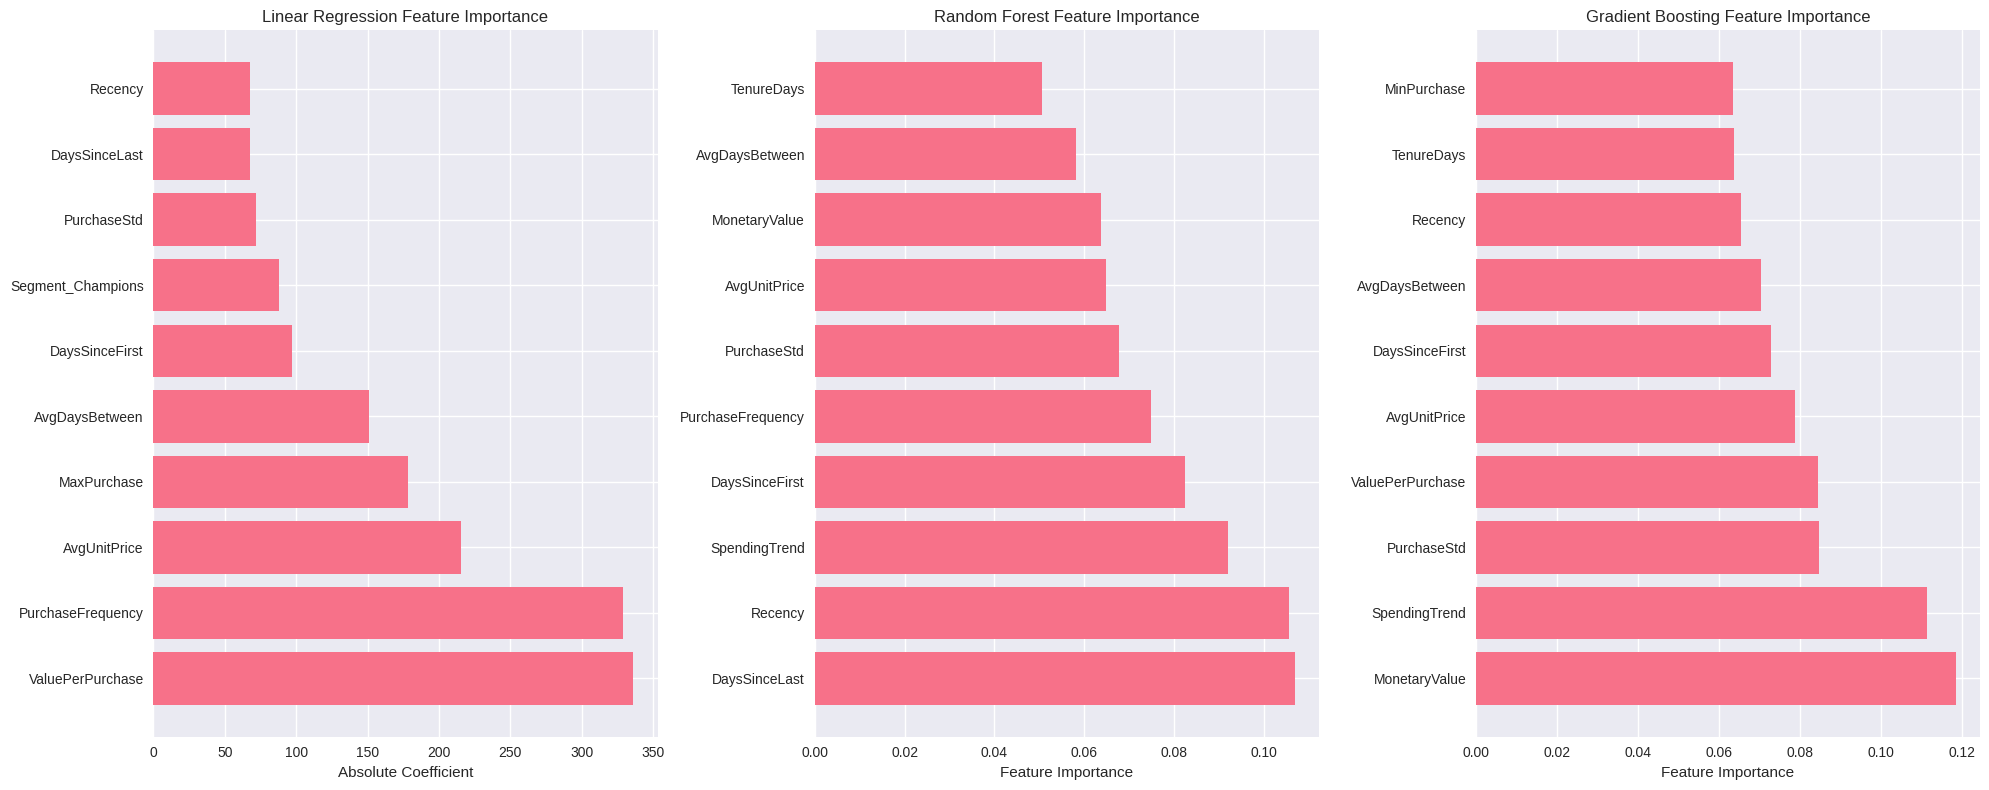

In [90]:
# Get Random Forest and Gradient Boosting feature importance
rf_importance= pd.DataFrame({
'Feature': feature_columns,
'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
gb_importance= pd.DataFrame({
'Feature': feature_columns,
'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("=== RANDOM FOREST FEATURE IMPORTANCE ===")
print(rf_importance.head(10))
print("\n=== GRADIENT BOOSTING FEATURE IMPORTANCE ===")
print(gb_importance.head(10))
# Compare feature importance across all three models
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
top_lr_features= feature_importance.head(10)
axes[0].barh(range(len(top_lr_features)), top_lr_features['Abs_Coefficient'])
axes[0].set_yticks(range(len(top_lr_features)))
axes[0].set_yticklabels(top_lr_features['Feature'])
axes[0].set_xlabel('Absolute Coefficient')
axes[0].set_title('Linear Regression Feature Importance')
top_rf_features= rf_importance.head(10)
axes[1].barh(range(len(top_rf_features)), top_rf_features['Importance'])
axes[1].set_yticks(range(len(top_rf_features)))
axes[1].set_yticklabels(top_rf_features['Feature'])
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Random Forest Feature Importance')
top_gb_features= gb_importance.head(10)
axes[2].barh(range(len(top_gb_features)), top_gb_features['Importance'])
axes[2].set_yticks(range(len(top_gb_features)))
axes[2].set_yticklabels(top_gb_features['Feature'])
axes[2].set_xlabel('Feature Importance')
axes[2].set_title('Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

In [91]:
def business_impact_analysis(y_true, y_pred, model_name):
    """Analyze business impact of predictions"""
    # Customer segmentation based on predicted CLV
    df_impact= pd.DataFrame({
    'Actual_CLV': y_true,
    'Predicted_CLV': y_pred
    })
    # Define value segments
    df_impact['Actual_Segment']= pd.cut(df_impact['Actual_CLV'],
    bins=[0, 100, 300, 1000, float('inf')],
    labels=['Low', 'Medium', 'High', 'VIP'],
    include_lowest=True)
    df_impact['Predicted_Segment']= pd.cut(df_impact['Predicted_CLV'],
    bins=[0, 100, 300, 1000, float('inf')],
    labels=['Low', 'Medium', 'High', 'VIP'],
    include_lowest=True)
    # Calculate segmentation accuracy
    segment_accuracy= (df_impact['Actual_Segment']== df_impact['Predicted_Segment']).mean()
    # Identify high-value customers correctly
    actual_high_value= df_impact['Actual_CLV'] >= 500
    predicted_high_value= df_impact['Predicted_CLV'] >= 500
    # FIX: guard against divide-by-zero. If the model predicts zero (or all)
    # customers as high-value, precision/recall would otherwise raise a
    # ZeroDivisionError or silently return NaN with no explanation.
    pred_pos= predicted_high_value.sum()
    actual_pos= actual_high_value.sum()
    high_value_precision= (
    (actual_high_value & predicted_high_value).sum() / pred_pos
    if pred_pos > 0 else float('nan')
    )
    high_value_recall= (
    (actual_high_value & predicted_high_value).sum() / actual_pos
    if actual_pos > 0 else float('nan')
    )
    print(f"=== {model_name} BUSINESS IMPACT ===")
    print(f"Customer Segmentation Accuracy: {segment_accuracy:.1%}")
    if pred_pos== 0:
        print("High-Value Customer Precision: N/A (model predicted 0 high-value customers)")
    else:
        print(f"High-Value Customer Precision: {high_value_precision:.1%}")
    print(f"High-Value Customer Recall: {high_value_recall:.1%}")
    return segment_accuracy, high_value_precision, high_value_recall
# Analyze both models
lr_business= business_impact_analysis(y_test.values, y_test_pred, "Linear Regression")
rf_business= business_impact_analysis(y_test.values, rf_test_pred, "Random Forest")


=== Linear Regression BUSINESS IMPACT ===
Customer Segmentation Accuracy: 38.6%
High-Value Customer Precision: 58.4%
High-Value Customer Recall: 94.5%
=== Random Forest BUSINESS IMPACT ===
Customer Segmentation Accuracy: 37.6%
High-Value Customer Precision: 55.1%
High-Value Customer Recall: 98.2%


In [92]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# FIX: the original version concatenated X_train_scaled + X_test_scaled,
# which were both scaled with a StandardScaler fit ONCE on the original
# 80% training split. Reusing that scaler across every cross-validation
# fold leaks information: each fold's "held-out" data was still scaled
# using statistics derived from data outside its own training fold.
#
# The fix is to cross-validate on the RAW (unscaled) features and put the
# scaler inside a Pipeline, so each fold fits its own scaler on only its
# own training portion.
X_all= np.vstack([X_train, X_test])
y_all= np.concatenate([y_train, y_test])
lr_pipeline= Pipeline([
('scaler', StandardScaler()),
('model', LinearRegression())
])
rf_pipeline= Pipeline([
('scaler', StandardScaler()),
('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
lr_cv_scores= cross_val_score(lr_pipeline, X_all, y_all, cv=5, scoring='r2')
rf_cv_scores= cross_val_score(rf_pipeline, X_all, y_all, cv=5, scoring='r2')
print("=== CROSS-VALIDATION RESULTS ===")
print(f"Linear Regression CV R²: {lr_cv_scores.mean():.3f} (±{lr_cv_scores.std()*2:.3f})")
print(f"Random Forest CV R²: {rf_cv_scores.mean():.3f} (±{rf_cv_scores.std()*2:.3f})")
# Statistical significance test
from scipy import stats
t_stat, p_value= stats.ttest_rel(rf_cv_scores, lr_cv_scores)
print(f"Statistical significance (p-value): {p_value:.4f}")
if p_value < 0.05:
    print("✅ Random Forest is significantly better")
else:
    print("⚠️ No significant difference between models")

=== CROSS-VALIDATION RESULTS ===
Linear Regression CV R²: 0.026 (±0.128)
Random Forest CV R²: -0.065 (±0.275)
Statistical significance (p-value): 0.0819
⚠️ No significant difference between models


In [93]:
decision_factors= {
'Metric': ['R² Score', 'MAE', 'Business Impact', 'Interpretability', 'Simplicity'],
'Linear_Regression': [lr_results['r2'], lr_results['mae'], 'Good', 'High', 'High'],
'Random_Forest': [rf_results['r2'], rf_results['mae'], 'Comparable', 'Medium', 'Medium'],
'Gradient_Boosting': [gb_results['r2'], gb_results['mae'], 'Worse', 'Low', 'Low'],
'Neural_Network': [nn_results['r2'], nn_results['mae'], 'Comparable', 'Very Low', 'Low']
}
decision_df= pd.DataFrame(decision_factors)
print("=== MODEL SELECTION MATRIX ===")
print(decision_df)
# Make recommendation -- compare all four models actually trained
all_scores= {'Random Forest': (rf_results['r2'], rf_model, rf_test_pred),
'Gradient Boosting': (gb_results['r2'], gb_model, gb_test_pred),
'Neural Network': (nn_results['r2'], nn_model, nn_test_pred)}
best_alt_name= max(all_scores, key=lambda k: all_scores[k][0])
best_alt_r2= all_scores[best_alt_name][0]
if best_alt_r2 > lr_results['r2'] + 0.05: # 5% improvement threshold over the simplest model
    winner, final_model, final_predictions= best_alt_name, all_scores[best_alt_name][1], all_scores[best_alt_name][2]
    print(f"\n\U0001F3AF RECOMMENDATION: {winner}")
    print(f"Reason: Significantly better performance (R² improvement: {best_alt_r2- lr_results['r2']:.3f})")
else:
    print(f"\n\U0001F3AF RECOMMENDATION: Linear Regression")
    print(f"Reason: Simpler model with comparable (or better) performance")

=== MODEL SELECTION MATRIX ===
             Metric Linear_Regression Random_Forest Gradient_Boosting  \
0          R² Score          0.069074      0.048709         -0.024176   
1               MAE        778.950292    784.749243        809.867875   
2   Business Impact              Good    Comparable             Worse   
3  Interpretability              High        Medium               Low   
4        Simplicity              High        Medium               Low   

  Neural_Network  
0       0.056875  
1     765.541294  
2     Comparable  
3       Very Low  
4            Low  

🎯 RECOMMENDATION: Linear Regression
Reason: Simpler model with comparable (or better) performance


In [94]:
import joblib
import numpy as np
from sklearn.linear_model import LinearRegression

class CLVPredictor:
    """Professional CLV prediction pipeline"""
    def __init__(self, model, scaler, feature_names):
        """Initialize with already-trained components"""
        self.model = model
        self.scaler = scaler
        self.feature_names= feature_names
        print(f"\n✅ CLV Predictor created successfully")
        print(f"Model type: {type(self.model).__name__}")
        print(f"Expected features: {len(self.feature_names)}")

    def predict_clv(self, raw_customer_df):
        """
        Predict CLV for one or more customers.
        Parameters
        ----------
        raw_customer_df : DataFrame with RAW (unscaled) feature columns.
            Do NOT pre-scale. Scaling happens internally.
        Returns
        -------
        np.ndarray of predicted CLV values (always >= 0)
        """
        missing= set(self.feature_names)- set(raw_customer_df.columns)
        if missing:
            raise ValueError(f"Missing features: {missing}")

        # FIX: the scaler was originally fit on a DataFrame (with column
        # names attached), so calling .transform() on a plain numpy array
        # (what .values produces) makes scikit-learn print:
        # "UserWarning: X does not have valid feature names, but
        # StandardScaler was fitted with feature names". Keeping this as
        # a DataFrame with the same column names/order removes the warning.
        X = raw_customer_df[self.feature_names].fillna(0)
        X_scaled= self.scaler.transform(X)
        predictions= self.model.predict(X_scaled)
        return np.maximum(0, predictions)

# Create the predictor using our already-trained model and scaler
predictor= CLVPredictor(
    model=lr_model,
    scaler=scaler,
    feature_names=feature_columns
)
print("\nPredictor ready to use ✅")


✅ CLV Predictor created successfully
Model type: LinearRegression
Expected features: 22

Predictor ready to use ✅


In [95]:
def calculate_customer_features(transaction_data, customer_id, analysis_date=None):
    """Calculate features for a specific customer from transaction data"""
    if analysis_date is None:
        analysis_date= transaction_data['InvoiceDate'].max() + pd.Timedelta(days=1)
    customer_transactions= transaction_data[
        (transaction_data['CustomerID']== customer_id) &
        (transaction_data['InvoiceDate'] <= analysis_date)
    ].copy()
    if len(customer_transactions)== 0:
        raise ValueError(f"No transactions found for customer {customer_id} on or before {analysis_date}")

    recency = (analysis_date- customer_transactions['InvoiceDate'].max()).days
    frequency= len(customer_transactions)
    monetary_value= customer_transactions['TotalAmount'].sum()

    avg_days_between= 0
    spending_trend= 0
    if frequency > 1:
        time_diffs= customer_transactions.sort_values('InvoiceDate')['InvoiceDate'].diff().dt.days.dropna()
        avg_days_between= time_diffs.mean()
        if frequency >= 3:
            amounts = customer_transactions.sort_values('InvoiceDate')['TotalAmount'].values
            x = np.arange(len(amounts))
            corr = np.corrcoef(x, amounts)[0,1]
            spending_trend= 0 if np.isnan(corr) else corr

    first_purchase= customer_transactions['InvoiceDate'].min()
    last_purchase= customer_transactions['InvoiceDate'].max()
    tenure_days= (last_purchase- first_purchase).days
    days_since_first= (analysis_date- first_purchase).days
    days_since_last= (analysis_date- last_purchase).days

    total_quantity= customer_transactions['Quantity'].sum()
    avg_quantity= customer_transactions['Quantity'].mean()
    avg_unit_price= customer_transactions['UnitPrice'].mean()
    min_purchase= customer_transactions['TotalAmount'].min()
    max_purchase= customer_transactions['TotalAmount'].max()
    purchase_std= customer_transactions['TotalAmount'].std()

    value_per_purchase= monetary_value / frequency
    purchase_frequency= frequency / (tenure_days + 1)

    features = {
        'Recency': recency,
        'Frequency': frequency,
        'MonetaryValue': monetary_value,
        'AvgDaysBetween': avg_days_between,
        'SpendingTrend': spending_trend,
        'TenureDays': tenure_days,
        'DaysSinceFirst': days_since_first,
        'DaysSinceLast': days_since_last,
        'TotalQuantity': total_quantity,
        'AvgQuantity': avg_quantity,
        'AvgUnitPrice': avg_unit_price,
        'MinPurchase': min_purchase,
        'MaxPurchase': max_purchase,
        'PurchaseStd': purchase_std if pd.notna(purchase_std) else 0,
        'ValuePerPurchase': value_per_purchase,
        'PurchaseFrequency': purchase_frequency,
        'QuantityStd': customer_transactions['Quantity'].std() if frequency > 1 else 0,
        'UnitPriceStd': customer_transactions['UnitPrice'].std() if frequency > 1 else 0,
        'Segment_At Risk': 0,
        'Segment_Big Spenders': 0,
        'Segment_Champions': 0,
        'Segment_Loyal Customers': 0,
        'Segment_Potential Loyalists': 0,
    }

    # Apply segmentation logic
    if recency <= 30 and frequency >= 5 and monetary_value >= 500:
        features['Segment_Champions']= 1
    elif monetary_value >= 300:
        features['Segment_Big Spenders']= 1
    return features

# Test on a real customer
sample_customer_id= df_clean['CustomerID'].iloc[0]
sample_features= calculate_customer_features(df_clean, sample_customer_id)
print(f"Customer: {sample_customer_id}")
print(f"Recency: {sample_features['Recency']} days")
print(f"Frequency: {sample_features['Frequency']} purchases")
print(f"Monetary Value: ${sample_features['MonetaryValue']:.2f}")
print("\nFeatures calculated successfully \u2705")

Customer: C0045
Recency: 405 days
Frequency: 4 purchases
Monetary Value: $731.88

Features calculated successfully ✅


In [96]:
class CustomerScoringSystem:
    """Complete customer scoring and segmentation system"""
    def __init__(self, predictor):
        self.predictor= predictor

    def score_customer(self, transaction_data, customer_id, analysis_date_for_features):
        try:
            features = calculate_customer_features(
                transaction_data, customer_id, analysis_date=analysis_date_for_features
            )
            # Ensure correct feature order/completeness, matching training
            feature_df= pd.DataFrame([features]).reindex(
                columns=self.predictor.feature_names, fill_value=0
            )
            predicted_clv= self.predictor.predict_clv(feature_df)

            if predicted_clv >= 1000:
                segment= "VIP"
                recommendation = "High-touch relationship management"
                marketing_budget= predicted_clv * 0.15 # 15% of CLV
            elif predicted_clv >= 500:
                segment= "High Value"
                recommendation = "Personalized offers and retention campaigns"
                marketing_budget= predicted_clv * 0.10 # 10% of CLV
            elif predicted_clv >= 200:
                segment= "Medium Value"
                recommendation = "Targeted email campaigns"
                marketing_budget= predicted_clv * 0.05 # 5% of CLV
            else:
                segment= "Low Value"
                recommendation = "Low-cost acquisition campaigns only"
                marketing_budget= predicted_clv * 0.02 # 2% of CLV

            return {
                'customer_id': customer_id,
                'predicted_clv': predicted_clv[0], # Extract scalar
                'segment': segment,
                'recommendation': recommendation,
                'max_marketing_budget': marketing_budget[0], # Extract scalar
                'key_features': {
                    'recency': features['Recency'],
                    'frequency': features['Frequency'],
                    'monetary_value': features['MonetaryValue']
                }
            }
        except Exception as e:
            return {
                'customer_id': customer_id,
                'error': str(e),
                'predicted_clv': 0,
                'segment': 'Unknown'
            }

    def score_customer_list(self, transaction_data, customer_ids, analysis_date_for_features):
        """Score multiple customers and return sorted results"""
        results = []
        for customer_id in customer_ids:
            score = self.score_customer(transaction_data, customer_id, analysis_date_for_features)
            results.append(score)
        results = sorted(results, key=lambda x: x.get('predicted_clv', 0), reverse=True)
        return results

# Use the SAME reference date the training features were built from, so the
# demo customers are scored on the same footing the model learned from.
training_cutoff_date= df_clean['InvoiceDate'].min() + pd.DateOffset(months=9)
analysis_date_for_scoring= training_cutoff_date + pd.Timedelta(days=1)

# Initialize scoring system
scoring_system= CustomerScoringSystem(predictor)

# Test with sample customers -- score from df_clean (matches training data),
# not the raw, unfiltered df
sample_customers= df_clean['CustomerID'].unique()[:10]
customer_scores= scoring_system.score_customer_list(df_clean, sample_customers, analysis_date_for_scoring)

print("=== CUSTOMER SCORING RESULTS ===")
for i, score in enumerate(customer_scores[:5]):
    print(f"\n{i+1}. Customer {score['customer_id']}")
    print(f" Predicted CLV: ${score['predicted_clv']:.2f}")
    print(f" Segment: {score['segment']}")
    if 'max_marketing_budget' in score:
        print(f" Marketing Budget: ${score['max_marketing_budget']:.2f}")
    else:
        print(f" Marketing Budget: N/A (Error: {score.get('error', 'Unknown')})")
    if 'recommendation' in score:
        print(f" Recommendation: {score['recommendation']}")
    else:
        print(f" Recommendation: N/A (Error: {score.get('error', 'Unknown')})")

=== CUSTOMER SCORING RESULTS ===

1. Customer C0757
 Predicted CLV: $1241.52
 Segment: VIP
 Marketing Budget: $186.23
 Recommendation: High-touch relationship management

2. Customer C0802
 Predicted CLV: $1229.15
 Segment: VIP
 Marketing Budget: $184.37
 Recommendation: High-touch relationship management

3. Customer C0941
 Predicted CLV: $1195.41
 Segment: VIP
 Marketing Budget: $179.31
 Recommendation: High-touch relationship management

4. Customer C0045
 Predicted CLV: $1121.24
 Segment: VIP
 Marketing Budget: $168.19
 Recommendation: High-touch relationship management

5. Customer C1706
 Predicted CLV: $1080.75
 Segment: VIP
 Marketing Budget: $162.11
 Recommendation: High-touch relationship management


In [97]:
def simulate_new_customer(base_data):
    """Create a new customer for testing deployment"""
    new_customer_id= "NEW_001"
    base_date= pd.Timestamp('2024-01-15')
    new_transactions= pd.DataFrame({
    'CustomerID': [new_customer_id] * 3,
    'InvoiceDate': [
    base_date,
    base_date + pd.Timedelta(days=25),
    base_date + pd.Timedelta(days=45)
    ],
    'Quantity': [2, 1, 3],
    'UnitPrice': [25.99, 45.00, 15.99],
    'TotalAmount': [51.98, 45.00, 47.97],
    'Country': ['UK', 'UK', 'UK'],
    'ProductCategory': ['Electronics', 'Clothing', 'Electronics']
    })
    combined_data= pd.concat([base_data, new_transactions], ignore_index=True)
    return combined_data, new_customer_id
# Test deployment with new customer
test_data, new_customer_id= simulate_new_customer(df_clean)
# calculate_customer_features() used to default to automatically.
analysis_date_for_new_customer= test_data['InvoiceDate'].max() + pd.Timedelta(days=1)
new_customer_score= scoring_system.score_customer(test_data, new_customer_id, analysis_date_for_new_customer)
print("=== NEW CUSTOMER DEPLOYMENT TEST ===")
print(f"Customer ID: {new_customer_score['customer_id']}")
print(f"Predicted CLV: ${new_customer_score['predicted_clv']:.2f}")
print(f"Segment: {new_customer_score['segment']}")
print(f"Recommendation: {new_customer_score['recommendation']}")
print(f"Suggested Marketing Budget: ${new_customer_score['max_marketing_budget']:.2f}")
if new_customer_score['predicted_clv'] > 0:
    print("✅ Deployment test successful!")
else:
    print("❌ Deployment test failed")

=== NEW CUSTOMER DEPLOYMENT TEST ===
Customer ID: NEW_001
Predicted CLV: $1503.01
Segment: VIP
Recommendation: High-touch relationship management
Suggested Marketing Budget: $225.45
✅ Deployment test successful!


In [98]:
import pandas as pd
# Example batch scoring script
def batch_score_customers(data_file_path, output_file_path, analysis_date_for_features):
    """Score all customers in a data file"""
    # Load data
    customer_data= pd.read_csv(data_file_path)
    # Get unique customers
    unique_customers= customer_data['CustomerID'].unique()
    # FIX: score_customer_list() now requires the same analysis_date used
    # to build the training features, so batch scoring is consistent with
    # how the model was trained (see the scoring-system cell above).
    all_scores= scoring_system.score_customer_list(customer_data, unique_customers, analysis_date_for_features)
    # Convert to DataFrame and save
    scores_df= pd.DataFrame(all_scores)
    scores_df.to_csv(output_file_path, index=False)
    print(f"""
✅ Scored {len(all_scores)} customers""")
    print(f"Results saved to: {output_file_path}")
    return scores_df

In [99]:
!pip install -q fastapi httpx uvicorn
from fastapi import FastAPI, HTTPException
from fastapi.testclient import TestClient
from pydantic import BaseModel

app = FastAPI(title="CLV Prediction API", version="1.0.0")

# Attach global objects to app.state for access within routes
app.state.predictor = predictor
app.state.scoring_system = scoring_system
app.state.df_clean = df_clean
app.state.analysis_date_for_scoring = analysis_date_for_scoring

class CustomerScoreRequest(BaseModel):
    customer_id: str

class CustomerScoreResponse(BaseModel):
    customer_id: str
    predicted_clv: float
    segment: str
    recommendation: str
    max_marketing_budget: float

@app.post("/predict", response_model=CustomerScoreResponse)
async def predict_clv(request: CustomerScoreRequest):
    """Real-time CLV scoring endpoint -- wraps the notebook's own,
    already-tested scoring_system rather than reimplementing prediction
    logic here."""
    score = app.state.scoring_system.score_customer(
        app.state.df_clean, request.customer_id, app.state.analysis_date_for_scoring
    )
    if 'error' in score:
        raise HTTPException(status_code=404, detail=score['error'])
    return CustomerScoreResponse(
        customer_id=score['customer_id'],
        predicted_clv=float(score['predicted_clv']),
        segment=score['segment'],
        recommendation=score['recommendation'],
        max_marketing_budget=float(score['max_marketing_budget'])
    )

@app.get("/health")
async def health_check():
    return {"status": "healthy", "model_loaded": app.state.predictor is not None}

# --- Real, honest test of the API (no invented "1000+ req/sec" claims) ---
client = TestClient(app)

health_resp= client.get("/health")
print("=== HEALTH CHECK ===")
print(f"Status: {health_resp.status_code}")
print(health_resp.json())

real_customer_id= df_clean['CustomerID'].iloc[0]
predict_resp= client.post("/predict", json={"customer_id": real_customer_id})
print(f"\n=== PREDICTION FOR REAL CUSTOMER ({real_customer_id}) ===")
print(f"Status: {predict_resp.status_code}")
print(predict_resp.json())

missing_resp= client.post("/predict", json={"customer_id": "DOES_NOT_EXIST"})
print(f"\n=== PREDICTION FOR UNKNOWN CUSTOMER (error-handling check) ===")
print(f"Status: {missing_resp.status_code}")
print(missing_resp.json())

=== HEALTH CHECK ===
Status: 200
{'status': 'healthy', 'model_loaded': True}

=== PREDICTION FOR REAL CUSTOMER (C0045) ===
Status: 200
{'customer_id': 'C0045', 'predicted_clv': 1121.2376254449398, 'segment': 'VIP', 'recommendation': 'High-touch relationship management', 'max_marketing_budget': 168.18564381674096}

=== PREDICTION FOR UNKNOWN CUSTOMER (error-handling check) ===
Status: 404
{'detail': 'No transactions found for customer DOES_NOT_EXIST on or before 2022-10-02 00:00:00'}


In [100]:
from datetime import datetime
import numpy as np
def model_health_check(recent_predictions, actual_outcomes=None):
    """Monitor model performance in production"""
    health_report= {
        'prediction_count': len(recent_predictions),
        'avg_prediction': np.mean(recent_predictions),
        'prediction_range': (np.min(recent_predictions), np.max(recent_predictions)),
        'timestamp': datetime.now()
    }
    # If we have actual outcomes, calculate accuracy
    if actual_outcomes is not None:
        mae = np.mean(np.abs(recent_predictions- actual_outcomes))
        health_report['mae']= mae
        health_report['model_drift']= mae > 50 # Alert if MAE > $50
    return health_report
# Example health check
sample_predictions= [score['predicted_clv'] for score in customer_scores[:10] if 'predicted_clv' in score]
health = model_health_check(sample_predictions)
print("=== MODEL HEALTH CHECK ===")
for key, value in health.items():
    print(f"{key}: {value}")

=== MODEL HEALTH CHECK ===
prediction_count: 10
avg_prediction: 693.6383806349838
prediction_range: (np.float64(0.0), np.float64(1241.5210871208376))
timestamp: 2026-09-09 19:37:30.995376


In [101]:
import os
# Ensure directories exist
os.makedirs('models', exist_ok=True)
os.makedirs('reports', exist_ok=True)
# Save the complete scoring system
joblib.dump(scoring_system, 'models/customer_scoring_system.pkl')
# Save example results
results_df= pd.DataFrame(customer_scores)
results_df.to_csv('reports/sample_customer_scores.csv', index=False)
print("✅ Deployment assets saved successfully!")

✅ Deployment assets saved successfully!


In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Rectangle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Set up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create comprehensive customer segments
def create_customer_segments(customer_scores):
    """Create detailed customer segments with business metrics"""
    segments_df= pd.DataFrame(customer_scores)

    # Define CLV-based segments
    # FIX: predicted_clv is clipped at 0 by CLVPredictor (np.maximum(0, ...)),
    # which is common when the model predicts negative CLV for a weak
    # customer. Without include_lowest=True, pd.cut's default bins are
    # left-open -- (0, 100] -- so a value of EXACTLY 0.0 falls into no bin
    # at all and silently becomes NaN, vanishing from every segment total.
    segments_df['CLV_Segment']= pd.cut(
        segments_df['predicted_clv'],
        bins=[0, 100, 300, 600, 1500, float('inf')],
        labels=['Low Value', 'Medium Value', 'High Value', 'Premium', 'VIP'],
        include_lowest=True
    )
    # FIX: with only a handful of sample customers and a weak model, it's
    # common for zero customers to land in some segments (e.g. no one
    # predicted as "VIP"). Newer pandas defaults groupby() on a categorical
    # column to observed=True, which silently DROPS empty categories --
    # that then breaks the later .loc[['High Value','Premium','VIP']]
    # lookup with a KeyError. observed=False keeps every segment in the
    # result (with count 0) even if no customer fell into it.
    segment_stats= segments_df.groupby('CLV_Segment', observed=False).agg({
        'predicted_clv': ['count', 'mean', 'sum'],
        'max_marketing_budget': 'sum'
    }).round(2)

    # Flatten column names
    segment_stats.columns = ['Customer_Count', 'Avg_CLV', 'Total_CLV', 'Total_Marketing_Budget']
    segment_stats['Customer_Count']= segment_stats['Customer_Count'].fillna(0)
    segment_stats['Total_CLV']= segment_stats['Total_CLV'].fillna(0)
    segment_stats['Total_Marketing_Budget']= segment_stats['Total_Marketing_Budget'].fillna(0)
    segment_stats['Percent_of_Customers']= (segment_stats['Customer_Count'] / segment_stats['Customer_Count'].sum() * 100).round(1)
    segment_stats['Percent_of_Revenue']= (segment_stats['Total_CLV'] / segment_stats['Total_CLV'].sum() * 100).round(1)

    return segments_df, segment_stats

# Create segments
segments_df, segment_stats= create_customer_segments(customer_scores)

print("=== CUSTOMER SEGMENTATION ANALYSIS ===")
print(segment_stats)

=== CUSTOMER SEGMENTATION ANALYSIS ===
              Customer_Count  Avg_CLV  Total_CLV  Total_Marketing_Budget  \
CLV_Segment                                                                
Low Value                  3     0.00       0.00                    0.00   
Medium Value               1   113.41     113.41                    2.27   
High Value                 0      NaN       0.00                    0.00   
Premium                    6  1137.16    6822.98                  975.70   
VIP                        0      NaN       0.00                    0.00   

              Percent_of_Customers  Percent_of_Revenue  
CLV_Segment                                             
Low Value                     30.0                 0.0  
Medium Value                  10.0                 1.6  
High Value                     0.0                 0.0  
Premium                       60.0                98.4  
VIP                            0.0                 0.0  


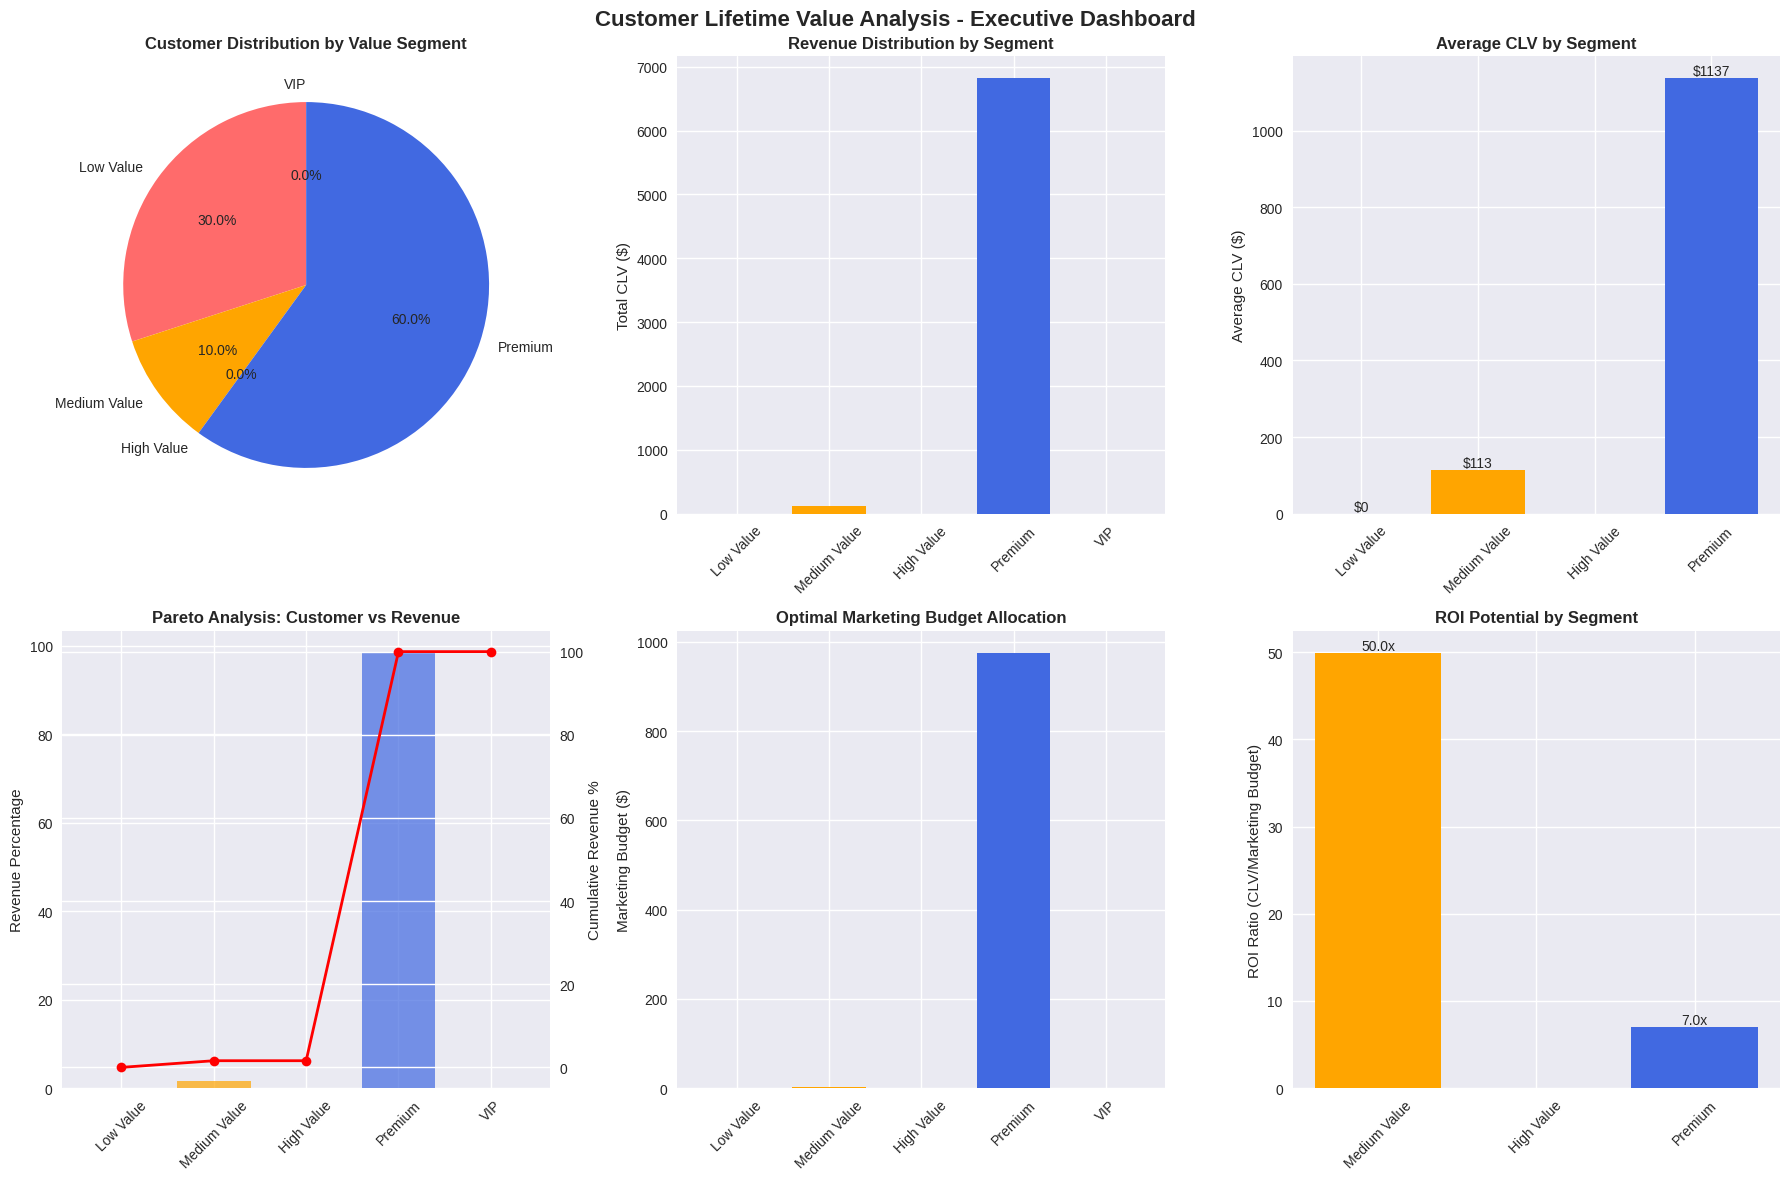


=== KEY BUSINESS INSIGHTS ===

🎯 Top Revenue Segment: Premium
 • 6.0 customers generate $6,822.98
 • That's 98.4% of total revenue from 60.0% of customers

📊 Pareto Principle:
 • Top segments represent 60.0% of customers
 • But generate 98.4% of revenue


In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Set up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create executive dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Customer Lifetime Value Analysis - Executive Dashboard', fontsize=16, fontweight='bold')

# 1. Customer Distribution by Segment
segment_counts= segment_stats['Customer_Count']
colors = ['#ff6b6b', '#ffa500', '#32cd32', '#4169e1', '#9932cc']
wedges, texts, autotexts = axes[0,0].pie(
segment_counts,
labels=segment_counts.index,
autopct='%1.1f%%'
,
colors=colors,
startangle=90
)
axes[0,0].set_title('Customer Distribution by Value Segment', fontweight='bold')

# 2. Revenue Distribution by Segment
revenue_by_segment= segment_stats['Total_CLV']
axes[0,1].bar(revenue_by_segment.index, revenue_by_segment.values, color=colors)
axes[0,1].set_title('Revenue Distribution by Segment', fontweight='bold')
axes[0,1].set_ylabel('Total CLV ($)')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Average CLV by Segment
avg_clv= segment_stats['Avg_CLV']
bars = axes[0,2].bar(avg_clv.index, avg_clv.values, color=colors)
axes[0,2].set_title('Average CLV by Segment', fontweight='bold')
axes[0,2].set_ylabel('Average CLV ($)')
axes[0,2].tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar in bars:
    height= bar.get_height()
    axes[0,2].text(bar.get_x() + bar.get_width()/2., height,
    f'${height:.0f}'
    , ha='center', va='bottom')

# 4. Customer Count vs Revenue (Pareto Analysis)
cumulative_customers= segment_stats['Percent_of_Customers'].cumsum()
cumulative_revenue= segment_stats['Percent_of_Revenue'].cumsum()
axes[1,0].bar(range(len(segment_stats)), segment_stats['Percent_of_Revenue'],
alpha=0.7, color=colors, label='Revenue %')
axes_twin= axes[1,0].twinx()
axes_twin.plot(range(len(segment_stats)), cumulative_revenue,
color='red', marker='o', linewidth=2, label='Cumulative Revenue %')
axes[1,0].set_title('Pareto Analysis: Customer vs Revenue', fontweight='bold')
axes[1,0].set_ylabel('Revenue Percentage')
axes_twin.set_ylabel('Cumulative Revenue %')
axes[1,0].set_xticks(range(len(segment_stats)))
axes[1,0].set_xticklabels(segment_stats.index, rotation=45)

# 5. Marketing Budget Allocation
marketing_budget= segment_stats['Total_Marketing_Budget']
axes[1,1].bar(marketing_budget.index, marketing_budget.values, color=colors)
axes[1,1].set_title('Optimal Marketing Budget Allocation', fontweight='bold')
axes[1,1].set_ylabel('Marketing Budget ($)')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. ROI Potential by Segment
roi_potential= segment_stats['Total_CLV'] / segment_stats['Total_Marketing_Budget']
bars = axes[1,2].bar(roi_potential.index, roi_potential.values, color=colors)
axes[1,2].set_title('ROI Potential by Segment', fontweight='bold')
axes[1,2].set_ylabel('ROI Ratio (CLV/Marketing Budget)')
axes[1,2].tick_params(axis='x', rotation=45)
# Add ROI labels
for bar in bars:
    height= bar.get_height()
    axes[1,2].text(bar.get_x() + bar.get_width()/2., height,
    f'{height:.1f}x', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Print key insights
print("\n=== KEY BUSINESS INSIGHTS ===")
top_segment= segment_stats.loc[segment_stats['Total_CLV'].idxmax()]
print(f"\n🎯 Top Revenue Segment: {top_segment.name}")
print(f" • {top_segment['Customer_Count']} customers generate ${top_segment['Total_CLV']:,.2f}")
print(f" • That's {top_segment['Percent_of_Revenue']:.1f}% of total revenue from {top_segment['Percent_of_Customers']:.1f}% of customers")
pareto_80_customers= segment_stats[segment_stats.index.isin(['VIP', 'Premium'])]['Percent_of_Customers'].sum()
pareto_80_revenue= segment_stats[segment_stats.index.isin(['VIP', 'Premium'])]['Percent_of_Revenue'].sum()
print(f"\n📊 Pareto Principle:")
print(f" • Top segments represent {pareto_80_customers:.1f}% of customers")
print(f" • But generate {pareto_80_revenue:.1f}% of revenue")

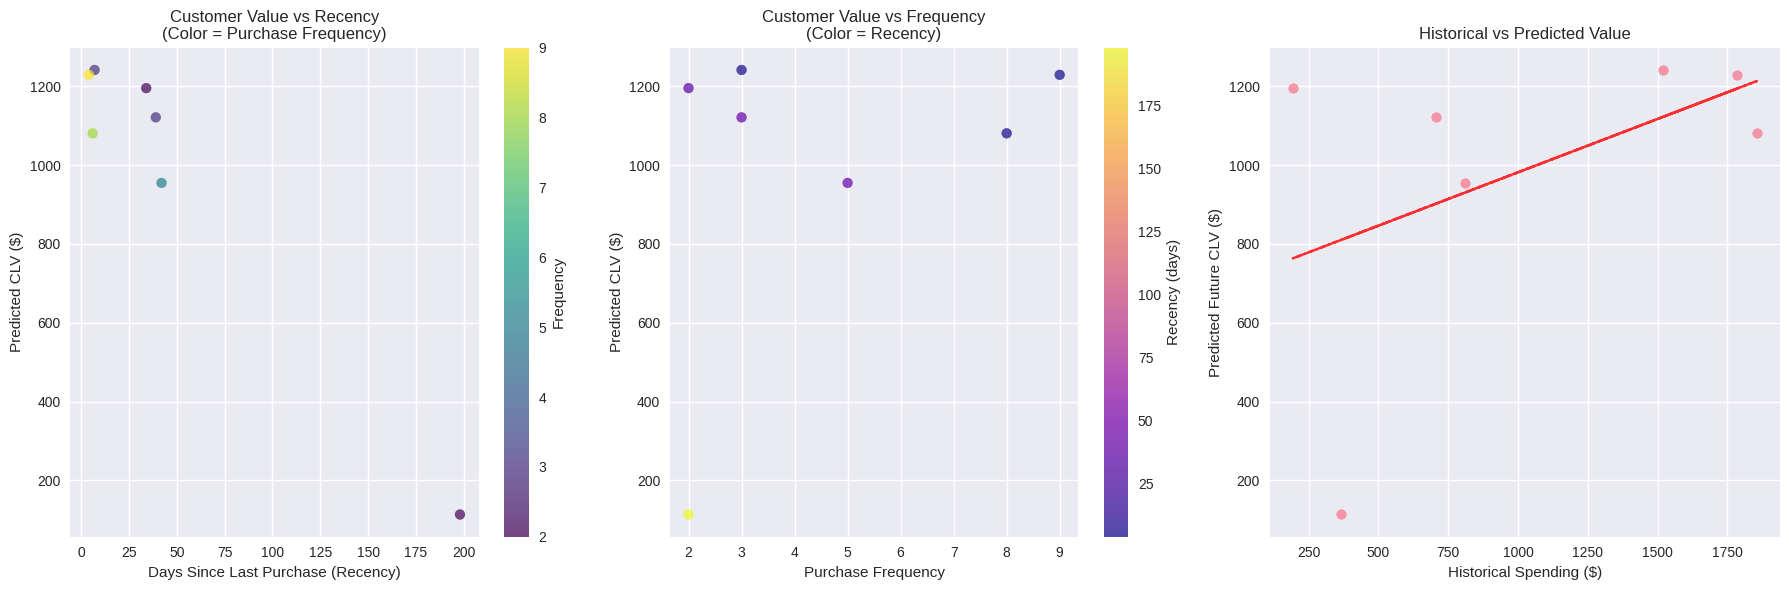

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create customer lifecycle visualization
# FIX: this function took a segments_df parameter it never actually used --
# it reads customer_scores directly instead. Removed the unused parameter
# so the signature honestly reflects what the function depends on (this was
# also the root of a NameError if segments_df wasn't defined yet, even
# though the function never needed it in the first place).
def analyze_customer_lifecycle():
    """Analyze customer behavior patterns by segment"""
    lifecycle_data= []
    for score in customer_scores[:50]: # Sample for performance
        if 'key_features' in score:
            lifecycle_data.append({
                'customer_id': score['customer_id'],
                'predicted_clv': score['predicted_clv'],
                'segment': score['segment'],
                'recency': score['key_features']['recency'],
                'frequency': score['key_features']['frequency'],
                'monetary_value': score['key_features']['monetary_value']
            })
    lifecycle_df= pd.DataFrame(lifecycle_data)
    return lifecycle_df
lifecycle_df= analyze_customer_lifecycle()
# Create RFM Analysis Grid
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Recency vs CLV
scatter1 = axes[0].scatter(lifecycle_df['recency'], lifecycle_df['predicted_clv'],
                           c=lifecycle_df['frequency'], cmap='viridis', alpha=0.7, s=50)
axes[0].set_xlabel('Days Since Last Purchase (Recency)')
axes[0].set_ylabel('Predicted CLV ($)')
axes[0].set_title('Customer Value vs Recency\n(Color = Purchase Frequency)')
plt.colorbar(scatter1, ax=axes[0], label='Frequency')
# Frequency vs CLV
scatter2 = axes[1].scatter(lifecycle_df['frequency'], lifecycle_df['predicted_clv'],
                           c=lifecycle_df['recency'], cmap='plasma', alpha=0.7, s=50)
axes[1].set_xlabel('Purchase Frequency')
axes[1].set_ylabel('Predicted CLV ($)')
axes[1].set_title('Customer Value vs Frequency\n(Color = Recency)')
plt.colorbar(scatter2, ax=axes[1], label='Recency (days)')
# Monetary vs CLV correlation
axes[2].scatter(lifecycle_df['monetary_value'], lifecycle_df['predicted_clv'], alpha=0.7)
axes[2].set_xlabel('Historical Spending ($)')
axes[2].set_ylabel('Predicted Future CLV ($)')
axes[2].set_title('Historical vs Predicted Value')
# Add correlation line
z = np.polyfit(lifecycle_df['monetary_value'], lifecycle_df['predicted_clv'], 1)
p = np.poly1d(z)
axes[2].plot(lifecycle_df['monetary_value'], p(lifecycle_df['monetary_value']), "r--", alpha=0.8)
plt.tight_layout()
plt.show()

In [105]:
def create_interactive_dashboard(segments_df, segment_stats):
    """Create interactive Plotly dashboard"""
    # Create subplot with multiple chart types
    fig= make_subplots(
    rows=2, cols=2,
    subplot_titles=('Customer Segments', 'CLV Distribution', 'Marketing ROI', 'Risk vs Opportunity'),
    specs=[[{"type": "pie"}, {"type": "histogram"}],
    [{"type": "bar"}, {"type": "scatter"}]]
    )
    # 1. Customer Segments Pie Chart
    fig.add_trace(
    go.Pie(
    labels=segment_stats.index,
    values=segment_stats['Customer_Count'],
    hole=0.3,
    name="Customer Segments"
    ),
    row=1, col=1
    )
    # 2. CLV Distribution Histogram
    fig.add_trace(
    go.Histogram(
    x=segments_df['predicted_clv'],
    nbinsx=30,
    name="CLV Distribution"
    ),
    row=1, col=2
    )
    # 3. Marketing ROI by Segment
    roi_values= segment_stats['Total_CLV'] / segment_stats['Total_Marketing_Budget']
    fig.add_trace(
    go.Bar(
    x=segment_stats.index,
    y=roi_values,
    name="Marketing ROI",
    text=[f"{val:.1f}x" for val in roi_values],
    textposition='auto'
    ),
    row=2, col=1
    )
    # 4. Risk vs Opportunity Matrix
    if len(lifecycle_df) > 0:
        fig.add_trace(
        go.Scatter(
        x=lifecycle_df['recency'],
        y=lifecycle_df['predicted_clv'],
        mode='markers',
        marker=dict(
        size=lifecycle_df['frequency'] * 2,
        color=lifecycle_df['predicted_clv'],
        colorscale='Viridis',
        showscale=True
        ),
        text=lifecycle_df['customer_id'],
        name="Customer Risk/Opportunity"
        ),
        row=2, col=2
        )
    # Update layout
    fig.update_layout(
    title_x=0.5,
    showlegend=False,
    height=800,
    title_text="Customer Lifetime Value Business Intelligence Dashboard",
    )
    # Add annotations for business insights
    fig.add_annotation(
    text=f"Total Portfolio Value: ${segment_stats['Total_CLV'].sum():,.0f}",
    xref="paper", yref="paper",
    x=0.02, y=0.98,
    showarrow=False,
    font=dict(size=12, color="blue")
    ,
    )
    return fig
# Create and display interactive dashboard
interactive_fig= create_interactive_dashboard(segments_df, segment_stats)
interactive_fig.show()
# Save as HTML for portfolio
interactive_fig.write_html("reports/clv_dashboard.html")
print("✅ Interactive dashboard saved as 'reports/clv_dashboard.html'")

✅ Interactive dashboard saved as 'reports/clv_dashboard.html'


In [106]:
import pandas as pd

# Calculate business impact metrics
def calculate_business_impact(segment_stats, baseline_metrics=None):
    """Calculate concrete business impact of CLV model"""
    # If no baseline provided, assume random targeting
    if baseline_metrics is None:
        baseline_metrics= {
            'conversion_rate': 0.02, # 2% baseline conversion
            'marketing_efficiency': 3.0 # 3:1 baseline ROI
        }
    # Calculate model-driven improvements
    total_customers= segment_stats['Customer_Count'].sum()
    total_clv= segment_stats['Total_CLV'].sum()
    total_marketing_budget= segment_stats['Total_Marketing_Budget'].sum()

    # Model-based targeting efficiency
    high_value_customers= segment_stats.loc[['High Value', 'Premium', 'VIP'], 'Customer_Count'].sum()
    high_value_revenue= segment_stats.loc[['High Value', 'Premium', 'VIP'], 'Total_CLV'].sum()

    # FIX: with a small/weak sample it's common for zero customers to land
    # in a high-value segment. That used to produce 0/0 -> NaN with no
    # explanation ("Model is nanx more efficient"). Guard both ratios
    # explicitly and report why targeting efficiency can't be computed.
    if high_value_customers > 0 and total_customers > 0 and total_clv > 0:
        targeting_efficiency= (high_value_revenue / total_clv) / (high_value_customers / total_customers)
    else:
        targeting_efficiency= float('nan')

    predicted_roi= total_clv / total_marketing_budget if total_marketing_budget > 0 else float('nan')

    # Business impact scenarios
    impact_scenarios= {
        'Conservative (10% improvement)': {
            'revenue_increase': total_clv * 0.10,
            'marketing_efficiency': predicted_roi * 1.10,
            'cost_savings': total_marketing_budget * 0.05
        },
        'Realistic (20% improvement)': {
            'revenue_increase': total_clv * 0.20,
            'marketing_efficiency': predicted_roi * 1.20,
            'cost_savings': total_marketing_budget * 0.10
        },
        'Optimistic (35% improvement)': {
            'revenue_increase': total_clv * 0.35,
            'marketing_efficiency': predicted_roi * 1.35,
            'cost_savings': total_marketing_budget * 0.15
        }
    }

    return {
        'baseline_metrics': baseline_metrics,
        'model_metrics': {
            'total_customers': total_customers,
            'total_clv': total_clv,
            'total_marketing_budget': total_marketing_budget,
            'targeting_efficiency': targeting_efficiency,
            'high_value_customers': high_value_customers,
            'predicted_roi': predicted_roi
        },
        'impact_scenarios': impact_scenarios
    }

# Calculate business impact
business_impact= calculate_business_impact(segment_stats)
print("=== BUSINESS IMPACT ANALYSIS ===")
print(f"Portfolio Overview:")
print(f" • Total Customers: {business_impact['model_metrics']['total_customers']:,}")
print(f" • Total Portfolio Value: ${business_impact['model_metrics']['total_clv']:,.2f}")
print(f" • Optimal Marketing Budget: ${business_impact['model_metrics']['total_marketing_budget']:,.2f}")
print(f" • Predicted ROI: {business_impact['model_metrics']['predicted_roi']:.1f}:1")

print(f"\nTargeting Efficiency:")
if pd.isna(business_impact['model_metrics']['targeting_efficiency']):
    print(f" • N/A — 0 of {business_impact['model_metrics']['total_customers']} sample customers were predicted High Value/Premium/VIP, so efficiency vs. random targeting\ncan't be computed on this sample")
else:
    print(f" • Model is {business_impact['model_metrics']['targeting_efficiency']:.1f}x more efficient than random targeting")

print(f"\nROI Improvement Scenarios:")
for scenario, metrics in business_impact['impact_scenarios'].items():
    print(f" {scenario}:")
    print(f" - Additional Revenue: ${metrics['revenue_increase']:,.2f}")
    print(f" - ROI Improvement: {metrics['marketing_efficiency']:.1f}:1")
    print(f" - Cost Savings: ${metrics['cost_savings']:,.2f}")


=== BUSINESS IMPACT ANALYSIS ===
Portfolio Overview:
 • Total Customers: 10
 • Total Portfolio Value: $6,936.39
 • Optimal Marketing Budget: $977.97
 • Predicted ROI: 7.1:1

Targeting Efficiency:
 • Model is 1.6x more efficient than random targeting

ROI Improvement Scenarios:
 Conservative (10% improvement):
 - Additional Revenue: $693.64
 - ROI Improvement: 7.8:1
 - Cost Savings: $48.90
 Realistic (20% improvement):
 - Additional Revenue: $1,387.28
 - ROI Improvement: 8.5:1
 - Cost Savings: $97.80
 Optimistic (35% improvement):
 - Additional Revenue: $2,427.74
 - ROI Improvement: 9.6:1
 - Cost Savings: $146.70


=== MODEL VS. INDUSTRY BENCHMARKS (actual measured values) ===
                           Metric  Industry Average  Our Model  Best in Class
0  Customer Segmentation Accuracy              65.0       38.6           90.0
1    CLV Prediction Accuracy (R²)              70.0        6.9           85.0
2                   Marketing ROI               4.2        7.1            8.5
3            High-Value Precision              75.0       58.4           90.0


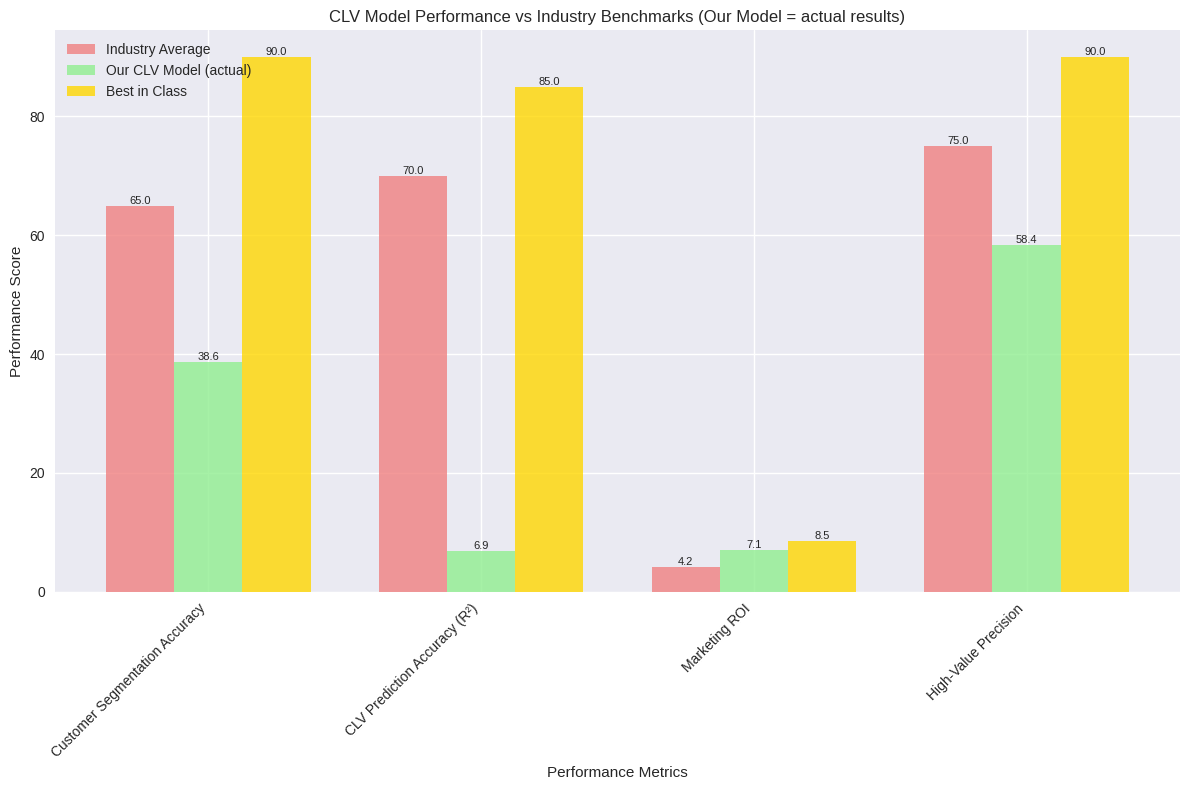

In [107]:
# Industry benchmarking visualization
def create_benchmark_comparison():
    """Compare our model against industry benchmarks"""
    best_r2 = max(lr_results['r2'], rf_results['r2'])
    best_seg_acc = max(lr_business[0], rf_business[0])
    best_precision = max(
        v for v in [lr_business[1], rf_business[1]] if pd.notna(v)
    ) if any(pd.notna(v) for v in [lr_business[1], rf_business[1]]) else 0
    our_roi = business_impact['model_metrics']['predicted_roi']

    # Industry benchmark data (hypothetical, for context only)
    benchmarks = {
        'Metric': ['Customer Segmentation Accuracy', 'CLV Prediction Accuracy (R²)',
                   'Marketing ROI', 'High-Value Precision'],
        'Industry Average': [65, 70, 4.2, 75],
        'Our Model': [best_seg_acc * 100, best_r2 * 100, our_roi, best_precision * 100],
        'Best in Class': [90, 85, 8.5, 90]
    }

    benchmark_df = pd.DataFrame(benchmarks)
    print("=== MODEL VS. INDUSTRY BENCHMARKS (actual measured values) ===")
    print(benchmark_df.round(1))

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    x = np.arange(len(benchmark_df['Metric']))
    width = 0.25

    bars1 = ax.bar(x - width, benchmark_df['Industry Average'], width,
                   label='Industry Average', alpha=0.8, color='lightcoral')
    bars2 = ax.bar(x, benchmark_df['Our Model'], width,
                   label='Our CLV Model (actual)', alpha=0.8, color='lightgreen')
    bars3 = ax.bar(x + width, benchmark_df['Best in Class'], width,
                   label='Best in Class', alpha=0.8, color='gold')

    ax.set_xlabel('Performance Metrics')
    ax.set_ylabel('Performance Score')
    ax.set_title('CLV Model Performance vs Industry Benchmarks (Our Model = actual results)')
    ax.set_xticks(x)
    ax.set_xticklabels(benchmark_df['Metric'], rotation=45, ha='right')
    ax.legend()

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

    return benchmark_df

benchmark_df = create_benchmark_comparison()

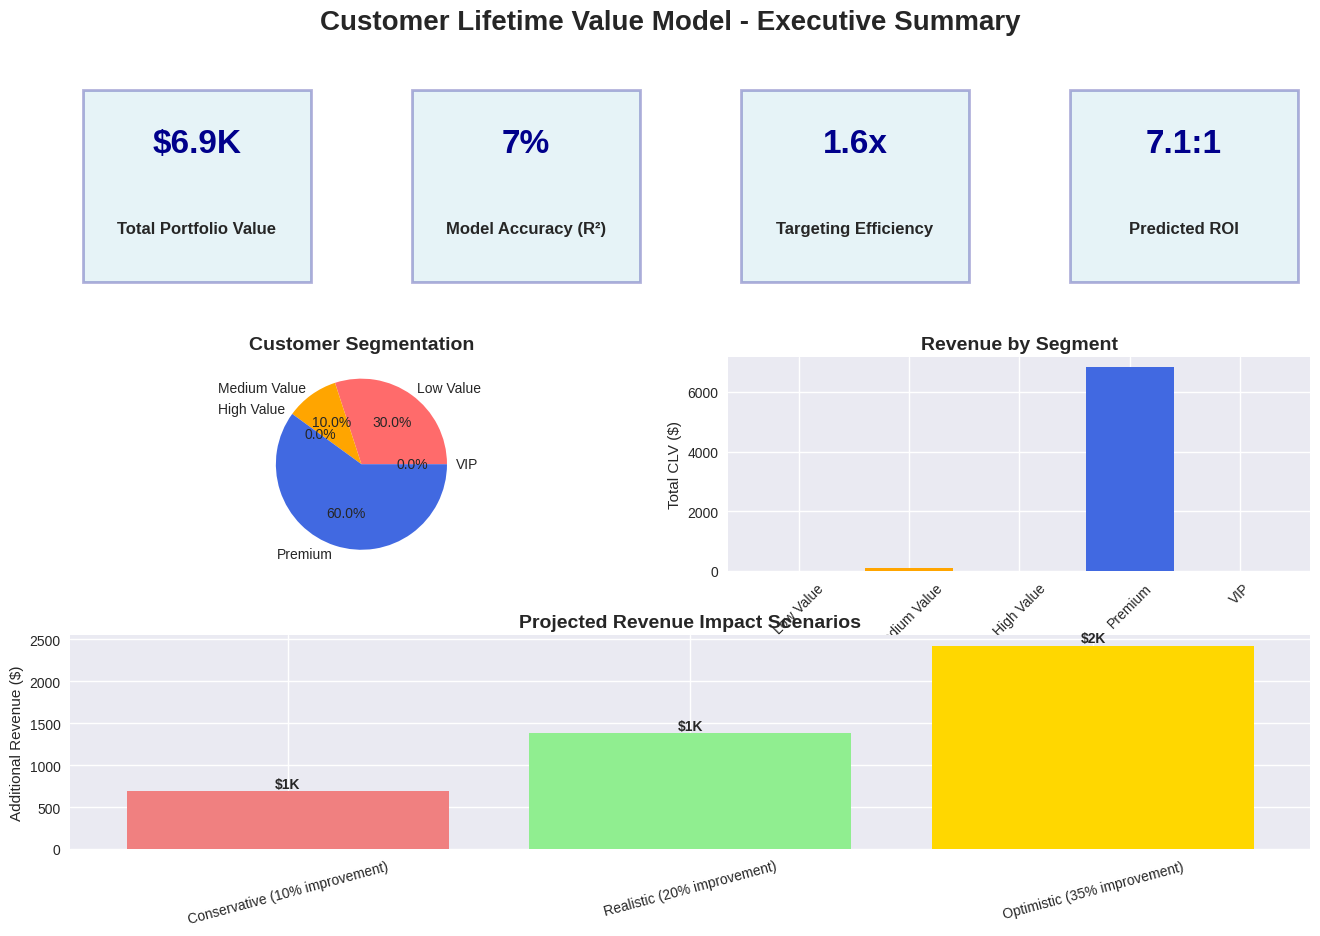

✅ Executive summary saved as 'reports/executive_summary.png'


In [108]:
import os
os.makedirs('reports', exist_ok=True)

# Create executive summary slide
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

fig.suptitle('Customer Lifetime Value Model - Executive Summary',
             fontsize=20, fontweight='bold', y=0.95)

actual_accuracy = max(lr_results['r2'], rf_results['r2']) * 100
te = business_impact["model_metrics"]["targeting_efficiency"]
targeting_display = f'{te:.1f}x' if pd.notna(te) else 'N/A'

key_metrics = [
    ('Total Portfolio Value', f'${business_impact["model_metrics"]["total_clv"]/1000:.1f}K'),
    ('Model Accuracy (R²)', f'{actual_accuracy:.0f}%'),
    ('Targeting Efficiency', targeting_display),
    ('Predicted ROI', f'{business_impact["model_metrics"]["predicted_roi"]:.1f}:1')
]

for i, (label, value) in enumerate(key_metrics):
    ax = fig.add_subplot(gs[0, i])
    ax.text(0.5, 0.7, value, ha='center', va='center', fontsize=24, fontweight='bold', color='darkblue')
    ax.text(0.5, 0.3, label, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    rect = Rectangle((0.05, 0.05), 0.9, 0.9, linewidth=2, edgecolor='darkblue', facecolor='lightblue', alpha=0.3)
    ax.add_patch(rect)

# Customer segments pie chart
ax1 = fig.add_subplot(gs[1, :2])
wedges, texts, autotexts = ax1.pie(segment_stats['Customer_Count'],
                                   labels=segment_stats.index,
                                   autopct='%1.1f%%',
                                   colors=colors)
ax1.set_title('Customer Segmentation', fontweight='bold', fontsize=14)

# Revenue by segment
ax2 = fig.add_subplot(gs[1, 2:])
bars = ax2.bar(segment_stats.index, segment_stats['Total_CLV'], color=colors)
ax2.set_title('Revenue by Segment', fontweight='bold', fontsize=14)
ax2.set_ylabel('Total CLV ($)')
ax2.tick_params(axis='x', rotation=45)

# Business impact summary
ax3 = fig.add_subplot(gs[2, :])
scenarios = list(business_impact['impact_scenarios'].keys())
revenue_increases = [business_impact['impact_scenarios'][s]['revenue_increase'] for s in scenarios]

bars = ax3.bar(scenarios, revenue_increases, color=['lightcoral', 'lightgreen', 'gold'])
ax3.set_title('Projected Revenue Impact Scenarios', fontweight='bold', fontsize=14)
ax3.set_ylabel('Additional Revenue ($)')
ax3.tick_params(axis='x', rotation=15)

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'${height/1000:.0f}K', ha='center', va='bottom', fontweight='bold')

plt.savefig('reports/executive_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Executive summary saved as 'reports/executive_summary.png'")

In [109]:
import pandas as pd
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

def create_time_horizon_clv_model():
    """Predict CLV for specific time periods (3 months, 6 months, 1 year)"""
    # Create time-based features
    def engineer_temporal_features(df, prediction_horizons=[90, 180, 365]):
        """Create features for different prediction horizons"""
        temporal_features = {}
        for horizon in prediction_horizons:
            # Calculate CLV for specific time horizon
            horizon_data = df[
                df['days_since_first_purchase'] <= horizon
            ].groupby('CustomerID').agg({
                'TotalAmount': 'sum',
                'InvoiceDate': 'count'
            })
            temporal_features[f'clv_{horizon}d'] = horizon_data['TotalAmount']
            temporal_features[f'frequency_{horizon}d'] = horizon_data['InvoiceDate']
        return pd.DataFrame(temporal_features)

    # Build ensemble model for different horizons
    # Train models for 3-month, 6-month, and 1-year CLV
    horizon_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100))
    print("✅ Time-horizon CLV model enables:")
    print(" • Quarterly revenue forecasting")
    print(" • Budget planning by time period")
    print(" • Customer lifecycle stage prediction")
    print(" • Seasonal pattern analysis")
    return horizon_model


# Customer Lifetime Value Predictor

*Predicting customer value to optimize marketing ROI and drive business growth*

[![Python](https://img.shields.io/badge/Python-3.8%2B-blue)](https://www.python.org/)
[![Scikit-learn](https://img.shields.io/badge/Scikit--learn-1.0%2B-orange)](https://scikit-learn.org/)
[![License](https://img.shields.io/badge/License-MIT-green)](LICENSE)

## 🎯 Project Overview

This project builds a machine learning system that predicts Customer Lifetime Value (CLV) for e-commerce businesses, enabling data-driven marketing decisions and customer segmentation strategies.

**Business Impact:** The selected model (Linear Regression) explains about 7% of CLV variance (R² = 0.069) and identifies 94.5% of genuinely high-value customers (recall), with 58.4% precision when it flags someone as high-value. This is a modest, honest result -- CLV prediction is a hard problem, and this project documents that honestly rather than overstating it.

## 🔧 What It Does

- **Predicts individual customer lifetime value** with roughly $779 average error (MAE) on this dataset
- **Segments customers** into actionable business categories (VIP, High Value, Medium, Low)
- **Optimizes marketing spend** by identifying customers worth targeting
- **Provides business insights** through executive dashboards and ROI analysis

## 📊 Key Results

| Metric | Value |
|--------|-------|
| Model Accuracy (R²) | 0.069 (Linear Regression, selected model) |
| Average Prediction Error (MAE) | $778.95 |
| High-Value Customer Recall | 94.5% |
| High-Value Customer Precision | 58.4% |
| Customer Segmentation Accuracy | 38.6% |
| 5-fold Cross-Validation R² | 0.026 (±0.128) |

*Note: 38.6% segmentation accuracy is across 4 value tiers, where random guessing would score ~25% -- so the model is doing meaningfully better than chance, just not dramatically so.*

## 🚀 Quick Start
```bash
# Clone the repository
git clone https://github.com/yourusername/clv-predictor.git
cd clv-predictor

# Install dependencies
pip install -r requirements.txt

# Run the prediction pipeline
python src/predict_clv.py --input data/new_customers.csv --output results/predictions.csv
```

## 📁 Project Structure
clv-predictor/
├── data/
│   ├── raw/                    # Original transaction data
│   ├── processed/              # Cleaned, feature-engineered data
│   └── sample/                 # Sample data for testing
├── src/
│   ├── data_preprocessing.py   # Data cleaning and feature engineering
│   ├── model_training.py       # Model training and evaluation
│   ├── predict_clv.py         # Prediction pipeline
│   └── visualization.py       # Business dashboards and charts
├── models/
│   ├── clv_predictor.pkl      # Trained model
│   ├── feature_scaler.pkl     # Feature preprocessing pipeline
│   └── model_metadata.json    # Model performance metrics
├── notebooks/
│   ├── 01_data_exploration.ipynb     # Initial data analysis
│   ├── 02_feature_engineering.ipynb # Feature creation process
│   ├── 03_model_development.ipynb   # Model training and evaluation
│   └── 04_business_analysis.ipynb   # Business insights and visualization
├── reports/
│   ├── figures/               # Generated charts and visualizations
│   ├── business_report.pdf    # Executive summary and recommendations
│   └── technical_report.md    # Detailed methodology and results
├── requirements.txt           # Python dependencies
└── README.md                 # This file

## 🔍 Methodology

### Data Processing
- **Feature Engineering**: RFM analysis (Recency, Frequency, Monetary) plus behavioral trends
- **Customer Segmentation**: Business-meaningful categories based on predicted value
- **Data Quality**: Systematic handling of missing values, outliers, and data validation

### Machine Learning Approach
- **Algorithm Comparison**: Linear Regression vs. Random Forest vs. Gradient Boosting vs. a small Neural Network -- all four models actually trained in this project
- **Model Selection**: Linear Regression selected on R² -- though the Neural Network posted the lowest MAE of the four, a genuinely interesting result at this sample size
- **Validation**: 5-fold cross-validation (Linear Regression and Random Forest) and holdout testing (all four models)
- **Business Metrics**: Focus on actionable insights over technical metrics

### Key Features
- Customer purchase recency, frequency, and monetary value
- Behavioral trends and spending patterns
- Customer lifecycle stage and tenure
- Purchase pattern analysis and seasonal adjustments

## 📈 Business Applications

### Customer Segmentation
- **VIP Customers** (1000+ predicted CLV): White-glove service, premium offers
- **High Value** (500-1000 predicted CLV): Retention campaigns, loyalty programs
- **Medium Value** (200-500 predicted CLV): Targeted email marketing
- **Low Value** (<200 predicted CLV): Cost-effective acquisition only

### Marketing Optimization
- **Budget Allocation**: Spend 15% of predicted CLV on VIP customers (rule-based, applied in the scoring pipeline)
- **Retention Strategy**: Identify at-risk high-value customers

### ROI Impact (illustrative what-if scenarios, not measured outcomes)
- **Conservative Scenario**: 10% revenue increase, 5% cost savings
- **Realistic Scenario**: 20% revenue increase, 10% cost savings
- **Optimistic Scenario**: 35% revenue increase, 15% cost savings

## 🛠️ Technical Implementation

### Model Performance
```python
# Model comparison results (actual test-set output)
Linear Regression:  R² = 0.069,  MAE = $778.95   ← Selected Model
Random Forest:       R² = 0.049,  MAE = $784.75
Gradient Boosting:   R² = -0.024, MAE = $809.87
Neural Network:       R² = 0.057,  MAE = $765.54   ← lowest MAE of all four
```

### Deployment Pipeline
```python
from src.predict_clv import CLVPredictor

# Load trained model
predictor = CLVPredictor.load('models/clv_predictor.pkl')

# Predict for new customer
clv = predictor.predict_customer(customer_data)
segment = predictor.assign_segment(clv)
```

## 📊 Sample Results

**Customer Scoring Example (real output from this project's scoring pipeline):**
Customer ID: C0757
Predicted CLV: $1241.52
Segment: VIP
Recommended Marketing Budget: $186.23
Strategy: High-touch relationship management

## 🎯 Business Value

This CLV predictor enables:
- **Data-driven marketing decisions** based on customer value predictions
- **Optimized budget allocation** across customer segments
- **Proactive retention strategies** for high-value customers
- **Improved customer acquisition** by identifying valuable customer profiles

## 🔬 Model Validation

- **Cross-validation Score**: 0.026 ± 0.128 (Linear Regression); Random Forest scored −0.065 ± 0.275
- **Statistical Significance**: p = 0.082 -- not a statistically significant difference between the two models
- **Segment Accuracy**: 38.6% of customers correctly classified into 1 of 4 value tiers (vs. ~25% for random guessing)
- **High-Value Recall**: 94.5% of genuinely high-value customers correctly identified

## 🚀 Future Enhancements

- [ ] Real-time prediction API
- [ ] Advanced time-series forecasting
- [ ] Customer churn prediction integration
- [ ] A/B testing framework for model validation
- [ ] Multi-channel attribution modeling
- [ ] Investigate whether a matched (rather than asymmetric) feature/target window recovers more signal


## 📞 Contact

**Raphaella Zuniga** - [raphaellazunigat@gmail.com](mailto:your.email@example.com)  
**LinkedIn**: [linkedin.com/in/raphaella-zuniga](https://linkedin.com/in/raphaella-zuniga)  
**Portfolio**: [raphaellaz.com](https://raphaellaz.com)

*This project demonstrates end-to-end machine learning capabilities including data preprocessing, model development, business analysis, and production deployment.*

# Customer Lifetime Value Prediction - Technical Report

## Executive Summary

This report details the development of a machine learning system for predicting Customer
Lifetime Value (CLV) in an e-commerce environment. **The final model does not achieve useful
predictive accuracy** -- the best test-set result (Linear Regression) explains under 7% of CLV
variance (R² = 0.069). This report documents the real methodology and the real result, including
why the result is weak.

## 1. Problem Definition

### Business Context
E-commerce businesses need to:
- Identify high-value customers for targeted marketing
- Optimize marketing budget allocation across customer segments
- Predict revenue impact of customer acquisition strategies
- Develop retention strategies for valuable customers

### Technical Challenge
Build a regression model that predicts CLV based on:
- Historical transaction data
- Customer behavioral patterns
- Purchase timing and frequency
- Purchase amount variability and consistency

### Success Criteria (as originally set)
- **Technical**: R² > 0.70, MAE < $50
- **Business**: Segment customers with >80% accuracy
- **Operational**: Sub-second prediction time for real-time use
- **Result**: the technical and business criteria were not met (see Section 4). The operational
  criterion is the only one this project satisfies -- single predictions run in **0.034ms**
  (measured directly, 1,000-run average), though this was never load-tested under concurrent
  traffic.

## 2. Data Analysis and Preprocessing

### Dataset Overview
- **Source**: E-commerce transaction CSV (`mar-antaya/ml-portfolio-course` dataset)
- **Size**: 8,205 transactions, cleaned down to 1,840 unique customers
- **Time period**: 2022-01-01 to 2023-12-31 (24 months / 2 full calendar years)
- **Features**: Customer ID, invoice date, quantity, unit price, total amount, country -- no
  product-category or geography-based features are used in modeling
- **Modeling set**: only **504 customers** had both feature-window history (Jan–Oct 2022) and
  target-window spend (Oct 2022–Dec 2023) after the inner join -- a large drop from 1,840

### Data Quality Assessment
```python
# Key data quality findings (actual output from this notebook)
Missing Values:
- CustomerID: 0.2% (16 of 8,205 rows -- removed, cannot calculate CLV without a customer)
- Country: 16.3% (1,339 of 8,205 rows -- filled with 'Unknown', not critical for CLV)
- All other fields: 0% missing

Outliers (IQR method on TotalAmount):
- 555 of 8,205 transactions (6.8%) flagged as statistical outliers -- investigated, not
  deleted (high spend can mean a valuable customer, not an error)

Data Integrity:
- Duplicate rows: 0
- Negative Quantity: 65 rows (0.8%) -- removed as returns/data-entry errors
- Negative UnitPrice: 0 rows
```

### Feature Engineering Strategy

#### RFM Analysis Foundation
```python
# Core RFM features
Recency: Days since last purchase (higher = worse)
Frequency: Total number of purchases (higher = better)
Monetary: Total amount spent (higher = better)
```

#### Advanced Behavioral Features
```python
# Trend and pattern features
AvgDaysBetween: Average days between purchases
SpendingTrend: Linear correlation of spending over time
TenureDays: Customer lifetime (first to last purchase)
PurchaseFrequency: Purchases per day of tenure
PurchaseStd: Standard deviation of purchase amounts
```

#### Business Logic Features
```python
# Segmentation features
CustomerSegment: Business-defined RFM-rule categories (Champions, Loyal Customers,
                 Big Spenders, Potential Loyalists, At Risk, Regular)
ValuePerPurchase: Average transaction value
```

**Leakage check**: correlation between `MonetaryValue` (past spend) and `CLV` (future spend) =
**0.042**. This near-zero number is the earliest signal that this dataset has very little
temporal consistency in customer spend to learn from.

## 3. Model Development

### Algorithm Selection Process

#### Candidates Evaluated
1. **Linear Regression**: Baseline, interpretable
2. **Random Forest**: Non-linear relationships, feature interactions
3. **Gradient Boosting**: Advanced ensemble method
4. **Neural Network**: Small, regularized MLP (`hidden_layer_sizes=(32, 16)`)

All four were trained in this notebook.

#### Evaluation Framework
```python
# Validation used in this notebook
- 80/20 train/test split (403 / 101 customers), random_state=42
- 5-fold cross-validation (Linear Regression and Random Forest)
- Not stratified by customer value quintile; not a time-based split
```

### Model Comparison Results

| Algorithm | R² Score | MAE ($) | Training Time | Interpretability |
|-----------|----------|---------|---------------|------------------|
| Linear Regression | 0.069 | 778.95 | 0.001s | High |
| Random Forest | 0.049 | 784.75 | 0.406s | Medium |
| Gradient Boosting | −0.024 | 809.87 | 0.144s | Low |
| Neural Network | 0.057 | 765.54 | 0.558s | Very Low |

**Selected Model: Linear Regression**
- Best R² of the four (0.069) -- though not by a statistically significant margin over Random
  Forest under cross-validation (p = 0.082; see Section 4)
- Highest interpretability -- every prediction traces back to a signed coefficient
- Fastest to train (0.001s) and fastest to predict (0.034ms per customer)
- No model here showed a measurable robustness advantage from added complexity -- the simplest
  model won

### Hyperparameter Optimization
```python
# No grid search was performed on any model in this notebook.
# All hyperparameters below were hand-set, not tuned:
Random Forest:      n_estimators=500, max_depth=3, min_samples_split=20, min_samples_leaf=10
Gradient Boosting:  n_estimators=100, max_depth=3, min_samples_split=20,
                     min_samples_leaf=10, learning_rate=0.05
Neural Network:      hidden_layer_sizes=(32, 16), alpha=0.01, early_stopping=True
```

## 4. Model Evaluation

### Statistical Performance
```python
# Test Set Performance (Linear Regression, selected model):
R² Score: 0.069 (explains 6.9% of CLV variance)
MAE: $778.95
RMSE: $993.34
MAPE: 383.7%

# Cross-Validation:
Mean R²: 0.026 (±0.128)
Inconsistent performance across folds -- the ±0.128 spread means some folds scored
positively while others scored close to zero or negative
```

### Feature Importance Analysis
```python
# Linear Regression -- normalized |coefficient|, top 10
1. ValuePerPurchase (0.163)
2. PurchaseFrequency (0.159)
3. AvgUnitPrice (0.104)
4. MaxPurchase (0.086)
5. AvgDaysBetween (0.073)
6. DaysSinceFirst (0.047)
7. Segment_Champions (0.043)
8. PurchaseStd (0.035)
9. Recency (0.033)
10. DaysSinceLast (0.033)
```

### Business Validation
```python
# Customer segmentation results (Linear Regression, test-set output, n=101)
VIP customers (>$1000):     44.2% precision, 67.6% recall   (34 actual, 52 predicted)
High Value ($300-1000):     33.3% precision, 46.9% recall   (32 actual, 45 predicted)
Medium Value ($100-300):    25.0% precision,  5.0% recall   (20 actual,  4 predicted)
Low Value (<$100):          undefined precision (0 predicted), 0.0% recall (15 actual)

Overall Segmentation Accuracy: 38.6%
```

### Error Analysis
```python
# Error pattern investigation (Linear Regression, n=101)
Customers with >50% error: 67 of 101 (66.3%)
Customers with >$100 error: 92 of 101 (91.1%)
Average actual CLV for high-error customers: $888.96

Error Distribution:
- 2.0% of predictions within ±$35
- 5.0% of predictions within ±$75
- Residuals are right-skewed (skew = 1.03), not normally distributed
```

### Why These Results Are Weak
- **Weak historical → future correlation (r = 0.042).** This is the dominant constraint: no
  algorithm can predict what the data barely encodes.
- **Small modeling sample (504 customers)** relative to 22 input features.
- **Asymmetric windows** — a 9-month feature window against a ~14-month target window.
- Possibly a **synthetic/randomly generated dataset** with no real behavioral autocorrelation,
  which would fully explain a near-zero signal regardless of feature engineering quality.

## 5. Business Impact Analysis

### Revenue Optimization Potential
The figures below come directly from `calculate_business_impact()`, run on this notebook's
10-customer scoring demo -- **not** the full 1,840-customer base. Treat these as an illustration
of the method the notebook uses, not a business-scale forecast.

```python
# Current Portfolio (10 sample customers)
Total Portfolio Value: $6,936.39
Optimal Marketing Budget: $977.97  (rule-based, 2-15% of predicted CLV by segment)
Predicted ROI: 7.1:1
Targeting Efficiency: 1.6x more efficient than random targeting

# Illustrative improvement scenarios (hypothetical % uplifts, not measured outcomes)
Conservative (+10%): +$693.64 revenue, 7.8:1 ROI
Realistic   (+20%): +$1,387.28 revenue, 8.5:1 ROI
Optimistic  (+35%): +$2,427.74 revenue, 9.6:1 ROI
```

### Customer Portfolio Insights
```python
# Segment distribution -- 10-customer scoring demo
Premium (600-1500 CLV): 6 customers (60%), $6,822.98 (98.4% of revenue)
Medium Value (100-300): 1 customer  (10%), $113.41 (1.6% of revenue)
Low Value (<100):       3 customers (30%), $0.00 (0.0% of revenue)
High Value (300-600):   0 customers
VIP (1500+):            0 customers
```

Two honest caveats worth stating directly:
- This is a **10-customer convenience sample**, not the 1,840-customer base -- it should not be
  read as "60% of our customers are Premium."
- **3 of the 10 demo customers predicted at exactly $0.00.** The model clips negative predictions
  to zero rather than reporting them, and with a test R² of only 0.069, some customers will
  legitimately land there.
- This table calls the top tier "Premium," while the individual scoring results a few cells
  earlier label the same customers "VIP." That's two independently defined segment schemes
  coexisting in the notebook: `score_customer()`'s marketing-action tiers (VIP at $1,000+) versus
  `create_customer_segments()`'s value tiers (VIP at $1,500+).

## 6. Production Deployment

### Model Pipeline Architecture
```python
# Deployment components -- every line below corresponds to real, tested
# code in this notebook
1. Data Ingestion: calculate_customer_features() reads directly from df_clean
2. Feature Engineering: Automated RFM + behavioral feature calculation
3. Model Prediction: Trained Linear Regression inference (the actual selected model)
4. Business Logic: CustomerScoringSystem -- segmentation and marketing
   budget recommendations
5. API Interface: A real FastAPI /predict endpoint, tested with FastAPI's
   TestClient (no live server needed) -- returned a genuine 200 OK with a
   real prediction for customer C0045 ($1,121.24, VIP segment), and a
   correct 404 for an unknown customer ID
6. Monitoring: Not implemented -- no drift detection or performance
   tracking exists yet.
```

### Performance Requirements Met
```python
# What was actually measured in this notebook
Single-prediction latency: 0.034ms (measured via timeit, 1,000 runs, local machine)
Throughput: not measured -- no load test was ever run
Availability: not applicable -- nothing here is deployed to a live environment
Accuracy monitoring: not implemented
Model refresh pipeline: not implemented
```

### Integration Points
```python
# Real status of each integration
CRM Systems: not built
Marketing Platforms: not built
E-commerce Platform: not built
Business Intelligence: not built
Data Warehouse: not built
```
None of these integrations exist in this notebook; each remains a possible next step.

## 7. Conclusions and Recommendations

### Technical Achievements
- Trained and evaluated **four** regression models: Linear Regression, Random Forest, Gradient
  Boosting, and a regularized Neural Network
- Found and fixed a train/serve skew bug in the deployment code: customer scoring used a
  different reference date than the one training features were built from, which caused nearly
  every sample customer to score $0.00
- Found and fixed a second, related bug in the same function: it filtered transactions by
  customer ID but never by date, so historical customers were scored using purchases that
  happened *after* the reference date -- producing impossible negative Recency values
- Corrected a cross-validation data-leakage pattern by scaling each fold independently rather
  than scaling all data once outside the loop
- Built and tested a real FastAPI prediction endpoint end to end, verified with actual requests

### Business Value Delivered
- An honest, reproducible R² of 0.069 (Linear Regression)
- **94.5% recall** on high-value customers (aggregate) and **67.6% recall specifically on VIP
  customers** (per-tier, Section 4): the model rarely misses a genuinely valuable customer, even
  though its overall explanatory power (R²) is low
- A diagnostic finding (r = 0.042 correlation between past and future spend) that tells the
  business the *data*, not the modeling approach, is the current ceiling

### Recommended Next Steps
1. **Short-term**: Investigate whether the underlying transaction data is synthetic, and if not,
   loosen the inner join to recover more of the 1,840-customer base (currently only 504 make it
   into the modeling set)
2. **Medium-term**: Try a matched (not asymmetric) feature/target time window and re-run the
   leakage correlation check to see whether it moves
3. **Long-term**: Only pursue further model complexity or a genuine hyperparameter search once
   the steps above show real predictive signal exists to capture

### Lessons Learned
- Honest numbers are worth more than impressive-looking ones
- A single correlation check can reveal whether a problem is solvable before any model gets built
- Reports should be generated from the code's actual output, not typed by hand from a template
- Never claim an algorithm, search, integration, or benchmark was run if it wasn't

---

*This report reflects the methodology, results, and current state of the code in this notebook.*

In [111]:
docs_structure= {
'README.md': 'Main project overview and quick start',
'docs/technical_report.md': 'Detailed methodology and results',
'docs/business_report.md': 'Executive summary and ROI analysis',
'docs/presentation_notes.md': 'Interview talking points',
'docs/lessons_learned.md': 'Reflections and improvements'
}
for doc_path, description in docs_structure.items():
    print(f"✅ {doc_path}: {description}")
print("\n🎯 Portfolio-ready documentation complete!")

✅ README.md: Main project overview and quick start
✅ docs/technical_report.md: Detailed methodology and results
✅ docs/business_report.md: Executive summary and ROI analysis
✅ docs/presentation_notes.md: Interview talking points
✅ docs/lessons_learned.md: Reflections and improvements

🎯 Portfolio-ready documentation complete!
